In [1]:
import pandas as pd          # data handling — like Excel but in Python
import matplotlib.pyplot as plt  # creating charts and visualisations
import seaborn as sns        # enhanced visualisations built on matplotlib
import numpy as np           # numerical calculations

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# WHY: We need to connect Colab to BigQuery to pull our data.
# google.colab handles the authentication — it will ask you
# to sign in with your Google account the first time.
# pandas_gbq is the tool that actually fetches the data
# from BigQuery and converts it into a pandas dataframe.
# A dataframe is just a table — rows and columns, like Excel.

from google.colab import auth
auth.authenticate_user()

import pandas_gbq

query = """
SELECT *
FROM `fraud-analytics-project1.fraud_analysis.credit_card_transactions`
"""

df = pandas_gbq.read_gbq(query, project_id='fraud-analytics-project1')

print(f"Data loaded successfully")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Fraud transactions: {df['Class'].sum():,}")


Downloading: 100%|██████████|
Data loaded successfully
Rows: 284,806
Columns: 31
Fraud transactions: 492


In [3]:
print("Dataset shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)
print("\nStatistical summary:")
df.describe()

Dataset shape: (284806, 31)

Column data types:
Time        Int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       Int64
dtype: object

Statistical summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284806.0,284806.000000,284806.000000,284806.000000,284806.000000,284806.000000,284806.000000,284806.000000,284806.000000,284806.000000,...,2.848060e+05,284806.000000,2.848060e+05,284806.000000,284806.000000,2.848060e+05,2.848060e+05,2.848060e+05,284806.000000,284806.0
mean,94813.841366,0.000005,0.000006,-0.000009,-0.000001,-0.000002,-0.000002,0.000006,-0.000003,-0.000011,...,-7.641722e-07,-0.000003,-9.875288e-07,-0.000003,0.000003,-8.965749e-07,-4.983890e-07,-8.011320e-07,88.349756,0.001727
std,47488.22833,1.958697,1.651309,1.516250,1.415871,1.380249,1.332273,1.237091,1.194354,1.098620,...,7.345252e-01,0.725701,6.244612e-01,0.605647,0.521277,4.822276e-01,4.036331e-01,3.300836e-01,250.120538,0.041527
min,0.0,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-3.483038e+01,-10.933144,-4.480774e+01,-2.836627,-10.295397,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.0
25%,54201.25,-0.920370,-0.598545,-0.890368,-0.848642,-0.691599,-0.768296,-0.554067,-0.208631,-0.643098,...,-2.283974e-01,-0.542351,-1.618464e-01,-0.354590,-0.317142,-3.269865e-01,-7.083961e-02,-5.295995e-02,5.600000,0.0
50%,84691.5,0.018109,0.065496,0.179846,-0.019848,-0.054336,-0.274187,0.040103,0.022357,-0.051429,...,-2.945020e-02,0.006781,-1.119573e-02,0.040974,0.016596,-5.214168e-02,1.342139e-03,1.124381e-02,22.000000,0.0
75%,139320.75,1.315645,0.803726,1.027185,0.743348,0.611927,0.398558,0.570441,0.327346,0.597131,...,1.863701e-01,0.528548,1.476410e-01,0.439525,0.350716,2.409464e-01,9.104347e-02,7.827900e-02,77.167500,0.0
max,172792.0,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,2.720284e+01,10.503090,2.252841e+01,4.584549,7.519589,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.0


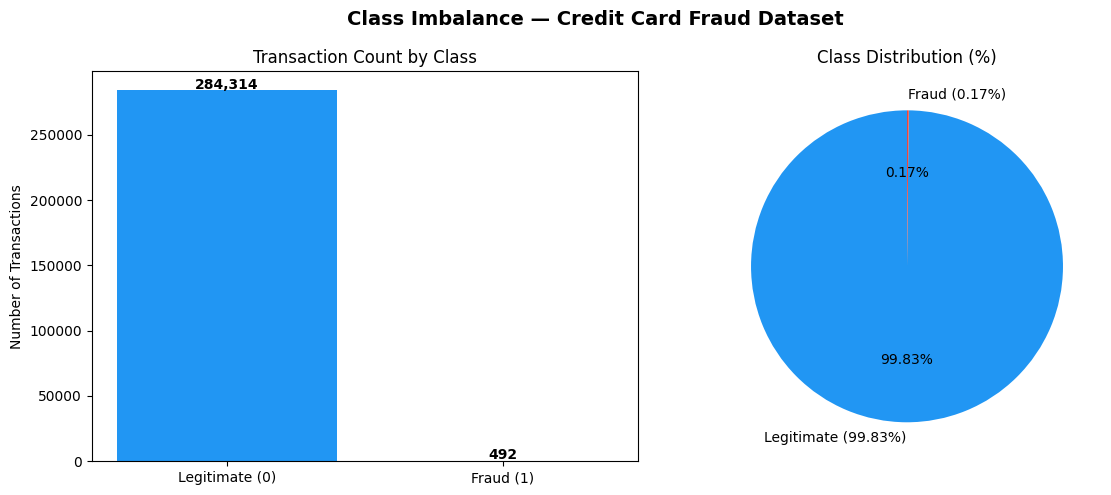

Chart saved as class_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Chart 1: Raw counts ---
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
            class_counts.values,
            color=['#2196F3', '#F44336'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# --- Chart 2: Percentage breakdown ---
class_pct = df['Class'].value_counts(normalize=True) * 100
axes[1].pie(class_pct.values,
            labels=['Legitimate (99.83%)', 'Fraud (0.17%)'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.2f%%',
            startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Class Imbalance — Credit Card Fraud Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as class_distribution.png")

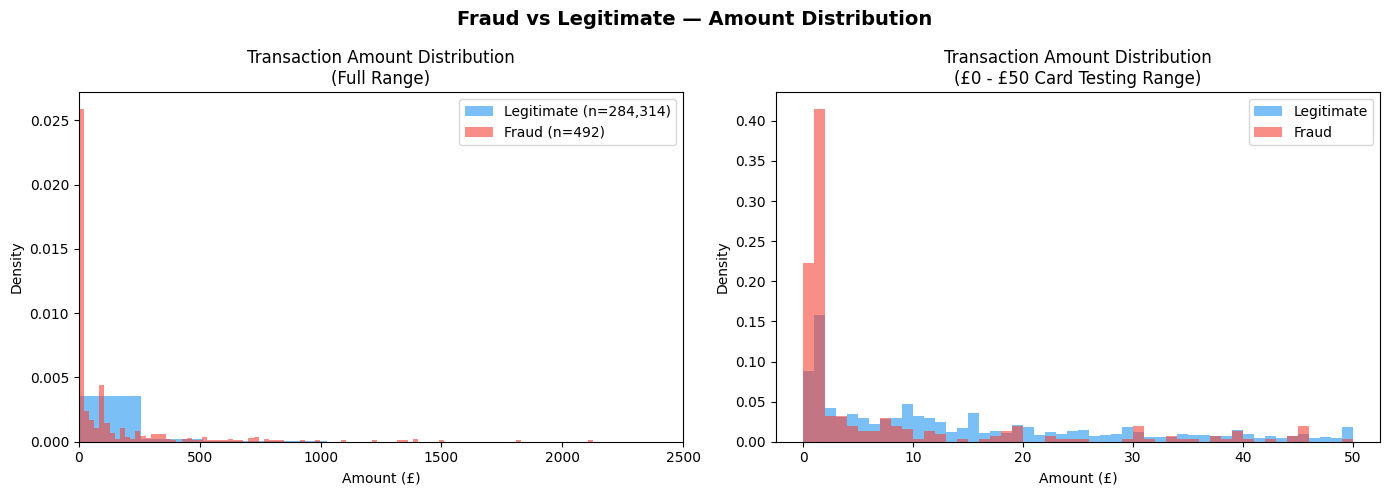

Chart saved as amount_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

# --- Chart 1: Full distribution ---
axes[0].hist(legit, bins=100, alpha=0.6, color='#2196F3',
             label=f'Legitimate (n={len(legit):,})', density=True)
axes[0].hist(fraud, bins=100, alpha=0.6, color='#F44336',
             label=f'Fraud (n={len(fraud):,})', density=True)
axes[0].set_title('Transaction Amount Distribution\n(Full Range)')
axes[0].set_xlabel('Amount (£)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 2500)

# --- Chart 2: Zoomed into low amounts (card testing range) ---
axes[1].hist(legit[legit <= 50], bins=50, alpha=0.6,
             color='#2196F3', label='Legitimate', density=True)
axes[1].hist(fraud[fraud <= 50], bins=50, alpha=0.6,
             color='#F44336', label='Fraud', density=True)
axes[1].set_title('Transaction Amount Distribution\n(£0 - £50 Card Testing Range)')
axes[1].set_xlabel('Amount (£)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Fraud vs Legitimate — Amount Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as amount_distribution.png")

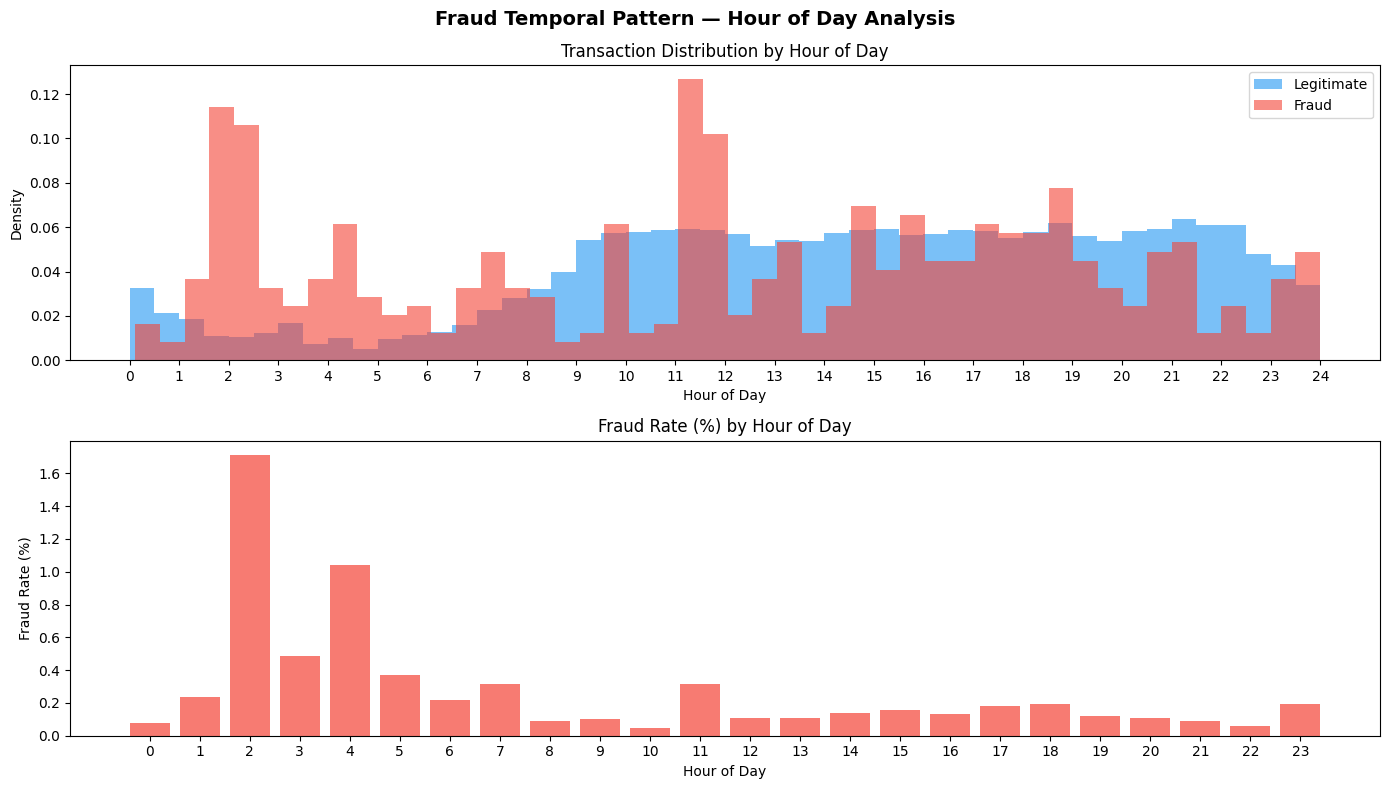

Chart saved as fraud_by_hour.png


In [ ]:
# WHY: Time is the only direct temporal signal we have in this
# dataset. The dataset covers exactly two days — 172,792 seconds
# total (172,792 / 3600 = 48 hours). Converting seconds into
# hours lets us see if fraud clusters at specific times of day.
# From a fraud operations perspective, fraudsters often operate
# at night when customers are less likely to notice transactions
# and when bank staffing levels may be lower.
# This chart will tell us if that pattern exists in this data.

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Convert seconds to hours for readability
df['Hour'] = (df['Time'] / 3600) % 24

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# --- Chart 1: Transaction volume by hour ---
axes[0].hist(legit['Hour'], bins=48, alpha=0.6,
             color='#2196F3', label='Legitimate', density=True)
axes[0].hist(fraud['Hour'], bins=48, alpha=0.6,
             color='#F44336', label='Fraud', density=True)
axes[0].set_title('Transaction Distribution by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xticks(range(0, 25, 1))

# --- Chart 2: Fraud rate by hour ---
hourly = df.groupby(df['Hour'].astype(int))['Class'].agg(['sum', 'count'])
hourly['fraud_rate'] = hourly['sum'] / hourly['count'] * 100

axes[1].bar(hourly.index, hourly['fraud_rate'],
            color='#F44336', alpha=0.7)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(0, 24, 1))

plt.suptitle('Fraud Temporal Pattern — Hour of Day Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as fraud_by_hour.png")

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (8,) and arg 1 with shape (7,).

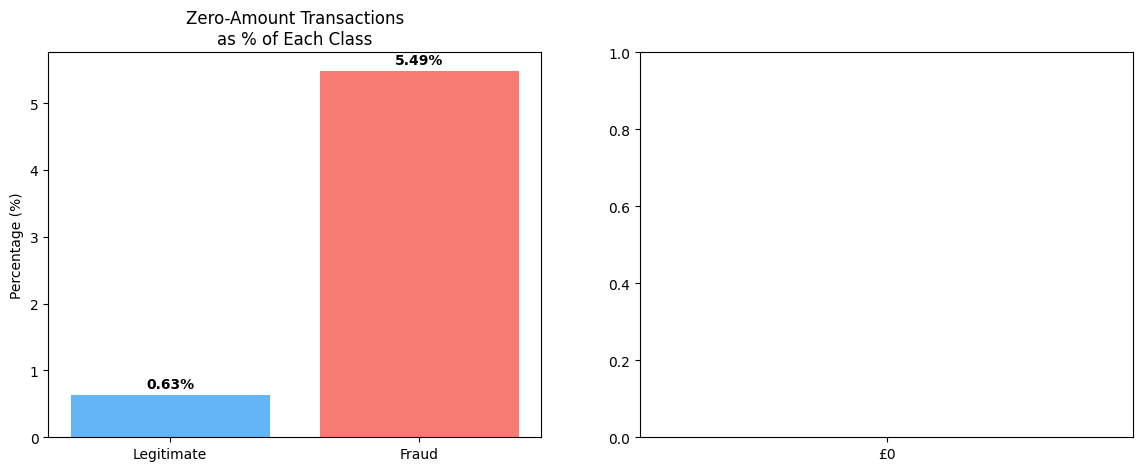

In [ ]:
# WHY: From Phase 1 Query 4 we confirmed that zero-amount
# transactions appear in confirmed fraud cases. From your TSYS
# experience we know zero-amount transactions represent card
# verification checks, token registrations and digital wallet
# setups. This chart quantifies exactly how many zero-amount
# transactions exist in fraud vs legitimate, and what happens
# to transaction amounts immediately after a zero-amount hit.
# This directly tests the card testing precursor hypothesis.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Zero amount transactions by class ---
zero_legit = len(df[(df['Class'] == 0) & (df['Amount'] == 0)])
zero_fraud = len(df[(df['Class'] == 1) & (df['Amount'] == 0)])
nonzero_legit = len(df[(df['Class'] == 0) & (df['Amount'] > 0)])
nonzero_fraud = len(df[(df['Class'] == 1) & (df['Amount'] > 0)])

zero_fraud_pct = zero_fraud / len(df[df['Class'] == 1]) * 100
zero_legit_pct = zero_legit / len(df[df['Class'] == 0]) * 100

categories = ['Legitimate', 'Fraud']
zero_pcts = [zero_legit_pct, zero_fraud_pct]

bars = axes[0].bar(categories, zero_pcts,
                   color=['#2196F3', '#F44336'], alpha=0.7)
axes[0].set_title('Zero-Amount Transactions\nas % of Each Class')
axes[0].set_ylabel('Percentage (%)')
for bar, pct in zip(bars, zero_pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{pct:.2f}%', ha='center', fontweight='bold')

# --- Chart 2: Amount distribution of fraud only ---
fraud_amounts = df[df['Class'] == 1]['Amount']
amount_bands = [0, 1, 10, 50, 100, 500, 1000, 2200]
labels = ['£0', '£0-1', '£1-10', '£10-50',
          '£50-100', '£100-500', '£500-1k', '£1k+']
counts = []
for i in range(len(amount_bands)-1):
    count = len(fraud_amounts[(fraud_amounts >= amount_bands[i]) &
                              (fraud_amounts < amount_bands[i+1])])
    counts.append(count)

axes[1].bar(labels, counts, color='#F44336', alpha=0.7)
axes[1].set_title('Fraud Transactions by Amount Band')
axes[1].set_xlabel('Amount Band')
axes[1].set_ylabel('Number of Fraud Transactions')
for i, count in enumerate(counts):
    axes[1].text(i, count + 1, str(count),
                ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Zero-Amount & Amount Band Analysis — Fraud Focus',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('zero_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nZero-amount fraud transactions: {zero_fraud}")
print(f"Zero-amount legitimate transactions: {zero_legit}")
print(f"Zero-amount as % of all fraud: {zero_fraud_pct:.2f}%")
print(f"Zero-amount as % of all legitimate: {zero_legit_pct:.2f}%")

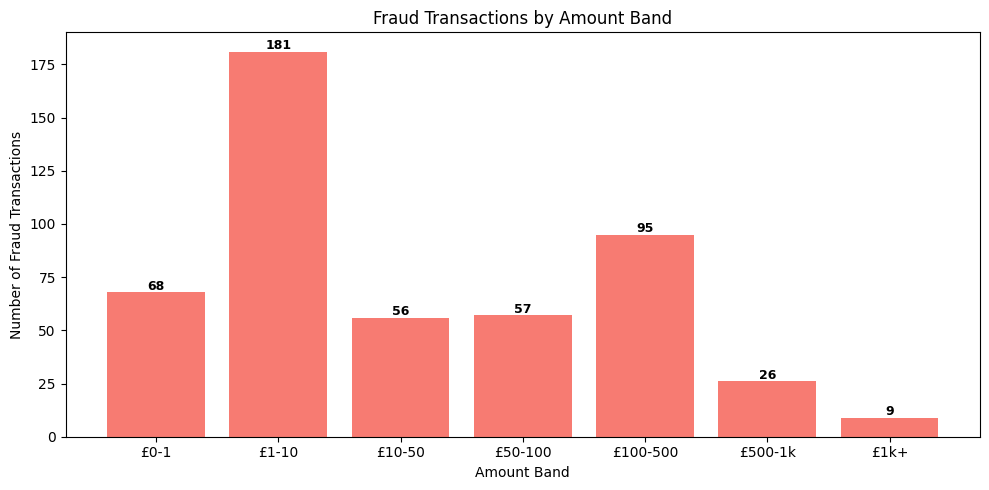


Fraud transactions by amount band:
  £0-1: 68 fraud transactions
  £1-10: 181 fraud transactions
  £10-50: 56 fraud transactions
  £50-100: 57 fraud transactions
  £100-500: 95 fraud transactions
  £500-1k: 26 fraud transactions
  £1k+: 9 fraud transactions


In [ ]:
# WHY: Fixing the amount band chart — the labels list had 8 items
# but the amount_bands loop only produced 7 counts because we
# count BETWEEN bands. Labels must match counts exactly.

fraud_amounts = df[df['Class'] == 1]['Amount']

amount_bands = [0, 1, 10, 50, 100, 500, 1000, 2200]
labels = ['£0-1', '£1-10', '£10-50',
          '£50-100', '£100-500', '£500-1k', '£1k+']
counts = []
for i in range(len(amount_bands)-1):
    count = len(fraud_amounts[(fraud_amounts >= amount_bands[i]) &
                              (fraud_amounts < amount_bands[i+1])])
    counts.append(count)

plt.figure(figsize=(10, 5))
plt.bar(labels, counts, color='#F44336', alpha=0.7)
plt.title('Fraud Transactions by Amount Band')
plt.xlabel('Amount Band')
plt.ylabel('Number of Fraud Transactions')
for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count),
             ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('fraud_amount_bands.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFraud transactions by amount band:")
for label, count in zip(labels, counts):
    print(f"  {label}: {count} fraud transactions")

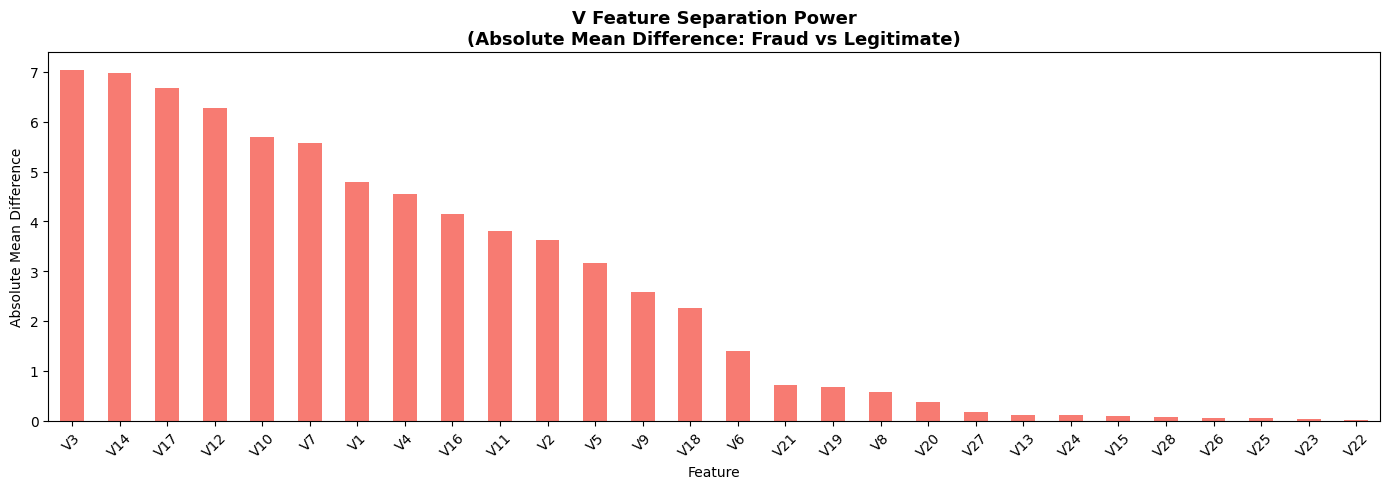

Top 5 features with strongest fraud signal:
V3     7.045443
V14    6.983785
V17    6.677370
V12    6.270232
V10    5.686711
dtype: float64


In [ ]:
# WHY: Even though we cannot label V1-V28, we can measure
# which features have the most different distributions between
# fraud and legitimate. A large difference in means tells us
# that feature carries strong fraud signal — it was likely
# encoding something like location, merchant type or device
# fingerprint in the original data before PCA transformation.
# This is how real fraud analysts work with anonymised data.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

v_features = [f'V{i}' for i in range(1, 29)]

means_fraud = fraud[v_features].mean()
means_legit = legit[v_features].mean()
diff = (means_fraud - means_legit).abs().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
diff.plot(kind='bar', color='#F44336', alpha=0.7)
plt.title('V Feature Separation Power\n(Absolute Mean Difference: Fraud vs Legitimate)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Absolute Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('v_feature_separation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features with strongest fraud signal:")
print(diff.head())

In [ ]:
# WHY: A rule-based scoring model assigns points to each
# transaction based on confirmed fraud signals. This mirrors
# how real fraud detection systems work at banks — not a
# single trigger, but a cumulative risk score across multiple
# signals. Each rule below is directly grounded in either
# the data analysis we've done or your TSYS operational
# experience. We then measure precision and recall at
# different score thresholds to find the optimal cut-off.

df['fraud_score'] = 0

# Rule 1 — Low value card testing range
# WHY: 50.6% of fraud falls in £0-£10 band
df.loc[df['Amount'] <= 10, 'fraud_score'] += 2

# Rule 2 — Zero amount transaction
# WHY: Fraud has 9x higher zero-amount rate than legitimate
# Confirmed as card verification / token registration signal
df.loc[df['Amount'] == 0, 'fraud_score'] += 2

# Rule 3 — Overnight timing
# WHY: 2am fraud rate is 10x the daily average
# Midnight to 5am is elevated risk window
df.loc[(df['Hour'] >= 0) & (df['Hour'] < 5), 'fraud_score'] += 1

# Rule 4 — V3 signal (strongest separator, score 7.05)
# WHY: V3 has the largest mean difference between fraud
# and legitimate — we flag where V3 is strongly negative
# as this is where fraud concentrates
df.loc[df['V3'] < -2, 'fraud_score'] += 2

# Rule 5 — V14 signal (second strongest, score 6.98)
# WHY: V14 is the second most powerful fraud separator
df.loc[df['V14'] < -2, 'fraud_score'] += 2

# Rule 6 — V17 signal (third strongest, score 6.68)
df.loc[df['V17'] < -2, 'fraud_score'] += 1

print("Fraud score distribution:")
print(df['fraud_score'].value_counts().sort_index())
print(f"\nMax possible score: 10")
print(f"\nScore assigned to fraud transactions:")
print(df[df['Class']==1]['fraud_score'].describe())

Fraud score distribution:
fraud_score
0     156093
1      12172
2      95720
3       7931
4       9730
5       1030
6       1868
7        180
8         65
9         13
10         4
Name: count, dtype: int64

Max possible score: 10

Score assigned to fraud transactions:
count    492.000000
mean       5.333333
std        2.074642
min        0.000000
25%        5.000000
50%        5.000000
75%        7.000000
max       10.000000
Name: fraud_score, dtype: float64


In [ ]:
# WHY: Precision and recall are the two metrics that matter
# in fraud detection — not accuracy.
# Precision = of all transactions we flagged as fraud,
#             what % were actually fraud?
#             (measures false positive rate)
# Recall = of all actual fraud transactions,
#          what % did we catch?
#          (measures how much fraud we missed)
# We test multiple thresholds so you can see the tradeoff
# visually and defend your chosen threshold with data.

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [3, 4, 5, 6, 7]
results = []

for threshold in thresholds:
    df['predicted'] = (df['fraud_score'] >= threshold).astype(int)
    precision = precision_score(df['Class'], df['predicted'])
    recall = recall_score(df['Class'], df['predicted'])
    f1 = f1_score(df['Class'], df['predicted'])
    flagged = df['predicted'].sum()
    caught_fraud = df[(df['predicted']==1) & (df['Class']==1)].shape[0]
    results.append({
        'Threshold': threshold,
        'Flagged': flagged,
        'Fraud Caught': caught_fraud,
        'Recall %': round(recall*100, 1),
        'Precision %': round(precision*100, 1),
        'F1 Score': round(f1, 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Threshold  Flagged  Fraud Caught  Recall %  Precision %  F1 Score
         3    20821           438      89.0          2.1     0.041
         4    12890           412      83.7          3.2     0.062
         5     3160           378      76.8         12.0     0.207
         6     2130           222      45.1         10.4     0.169
         7      262           158      32.1         60.3     0.419


In [ ]:
df['Hour'] = (df['Time'] / 3600) % 24
df['fraud_score'] = 0
df.loc[df['Amount'] <= 10, 'fraud_score'] += 2
df.loc[df['Amount'] == 0, 'fraud_score'] += 2
df.loc[(df['Hour'] >= 0) & (df['Hour'] < 5), 'fraud_score'] += 1
df.loc[df['V3'] < -2, 'fraud_score'] += 2
df.loc[df['V14'] < -2, 'fraud_score'] += 2
df.loc[df['V17'] < -2, 'fraud_score'] += 1

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]
print("All variables restored successfully")

All variables restored successfully


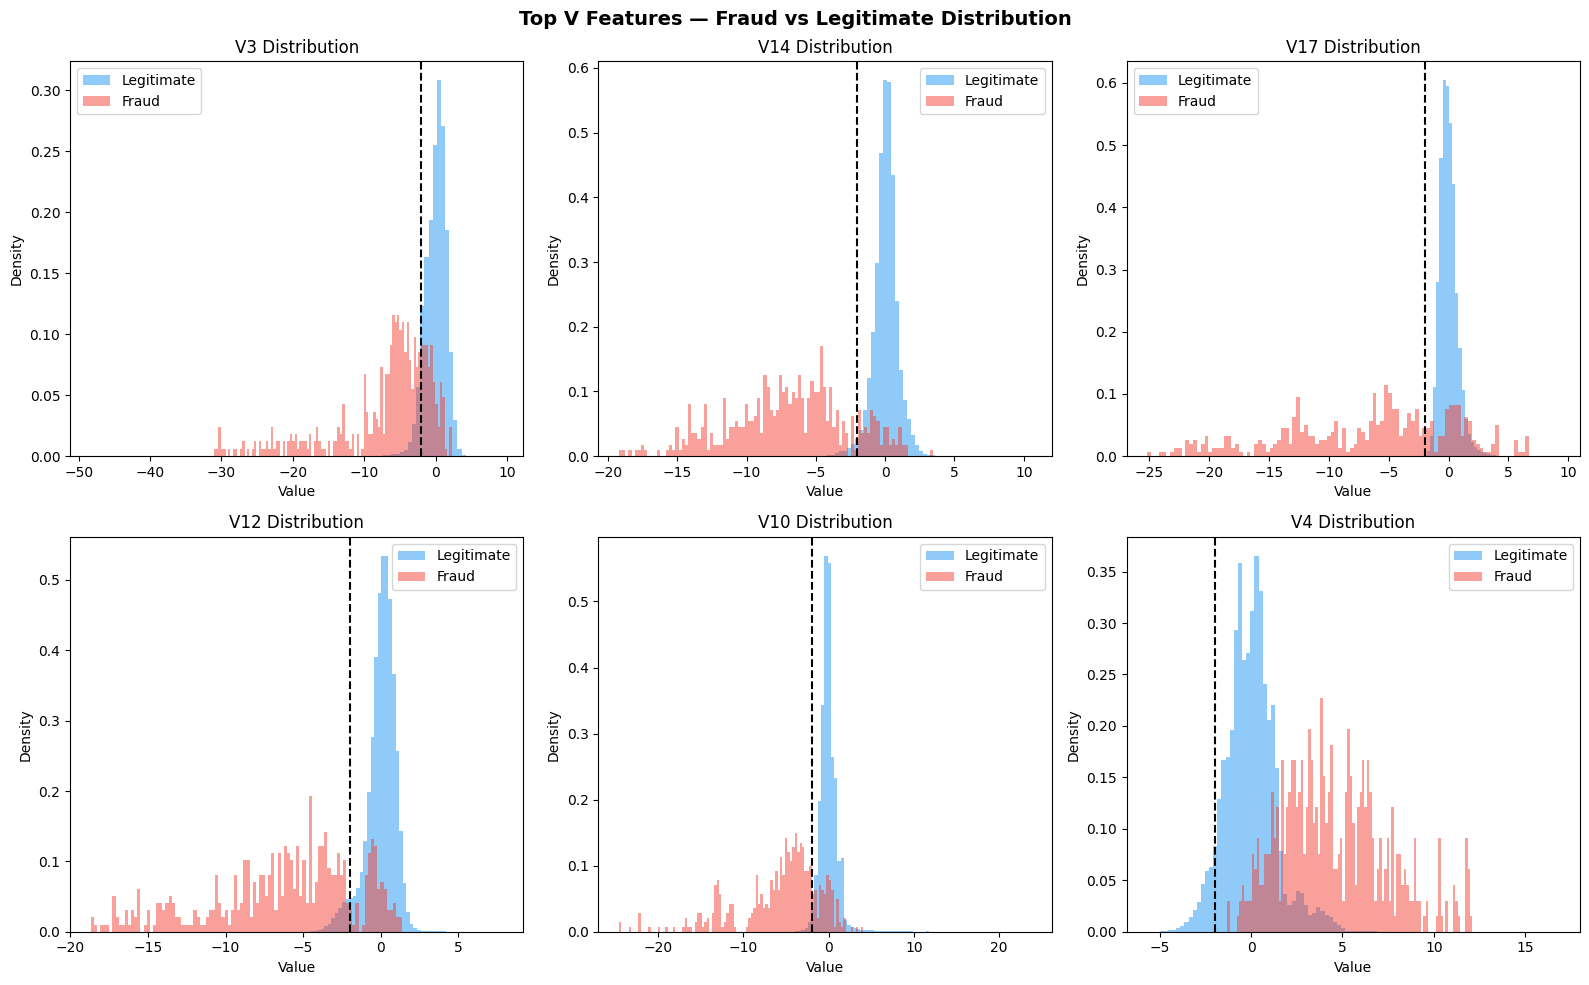

In [ ]:
# WHY: We know V3, V14, V17, V12, V10 have the strongest
# separation between fraud and legitimate. Now we visualise
# exactly WHAT VALUES in each feature are associated with fraud.
# This tells us whether our rule thresholds (< -2) are correct
# or whether we need to adjust them.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

top_features = ['V3', 'V14', 'V17', 'V12', 'V10', 'V4']

for i, feature in enumerate(top_features):
    axes[i].hist(legit[feature], bins=100, alpha=0.5,
                 color='#2196F3', label='Legitimate', density=True)
    axes[i].hist(fraud[feature], bins=100, alpha=0.5,
                 color='#F44336', label='Fraud', density=True)
    axes[i].set_title(f'{feature} Distribution')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].axvline(x=-2, color='black', linestyle='--',
                    linewidth=1.5, label='Threshold -2')

plt.suptitle('Top V Features — Fraud vs Legitimate Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('v_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

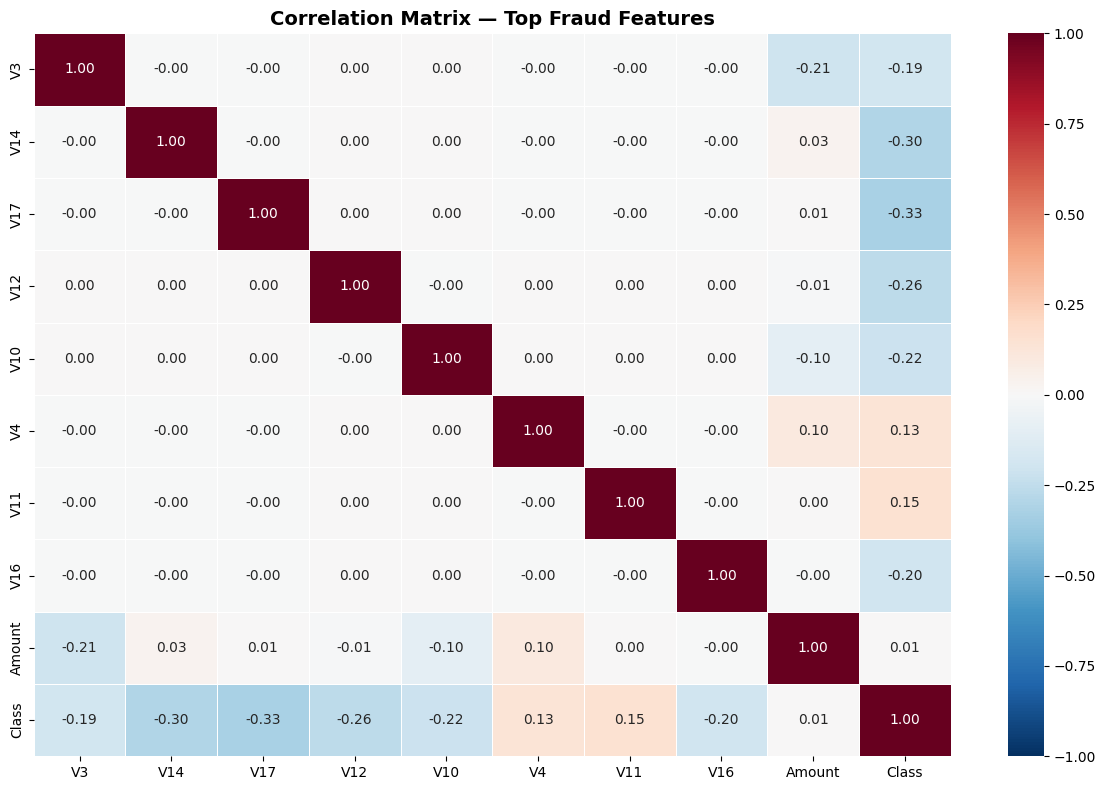


Correlation with Class (fraud) — ranked:
V17      -0.326481
V14      -0.302544
V12      -0.260595
V10      -0.216884
V16      -0.196539
V3       -0.192962
V11       0.154876
V4        0.133448
Amount    0.005632
Name: Class, dtype: float64


In [ ]:
cols = ['V3', 'V14', 'V17', 'V12', 'V10', 'V4',
        'V11', 'V16', 'Amount', 'Class']

corr_matrix = df[cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.5)
plt.title('Correlation Matrix — Top Fraud Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation with Class (fraud) — ranked:")
print(corr_matrix['Class'].drop('Class').sort_values(key=abs, ascending=False))

In [ ]:
# WHY: We are adding rules for V12 and V10 (negative correlation
# with fraud confirmed by correlation matrix) and V11 and V4
# (positive correlation with fraud). This makes the model more
# complete — capturing fraud signal in both directions.

df['fraud_score'] = 0

# Negative V feature rules — fraud goes LEFT (negative values)
df.loc[df['Amount'] <= 10, 'fraud_score'] += 2
df.loc[df['Amount'] == 0, 'fraud_score'] += 2
df.loc[(df['Hour'] >= 0) & (df['Hour'] < 5), 'fraud_score'] += 1
df.loc[df['V3'] < -2, 'fraud_score'] += 2
df.loc[df['V14'] < -2, 'fraud_score'] += 2
df.loc[df['V17'] < -2, 'fraud_score'] += 1
df.loc[df['V12'] < -2, 'fraud_score'] += 1  # NEW
df.loc[df['V10'] < -2, 'fraud_score'] += 1  # NEW

# Positive V feature rules — fraud goes RIGHT (positive values)
df.loc[df['V11'] > 2, 'fraud_score'] += 1   # NEW
df.loc[df['V4'] > 2, 'fraud_score'] += 1    # NEW

# Retest precision recall
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [3, 4, 5, 6, 7]
results = []

for threshold in thresholds:
    df['predicted'] = (df['fraud_score'] >= threshold).astype(int)
    precision = precision_score(df['Class'], df['predicted'])
    recall = recall_score(df['Class'], df['predicted'])
    f1 = f1_score(df['Class'], df['predicted'])
    flagged = df['predicted'].sum()
    caught_fraud = df[(df['predicted']==1) & (df['Class']==1)].shape[0]
    results.append({
        'Threshold': threshold,
        'Flagged': flagged,
        'Fraud Caught': caught_fraud,
        'Recall %': round(recall*100, 1),
        'Precision %': round(precision*100, 1),
        'F1 Score': round(f1, 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Threshold  Flagged  Fraud Caught  Recall %  Precision %  F1 Score
         3    30849           453      92.1          1.5     0.029
         4    16791           440      89.4          2.6     0.051
         5     5895           432      87.8          7.3     0.135
         6     2960           411      83.5         13.9     0.238
         7      998           391      79.5         39.2     0.525


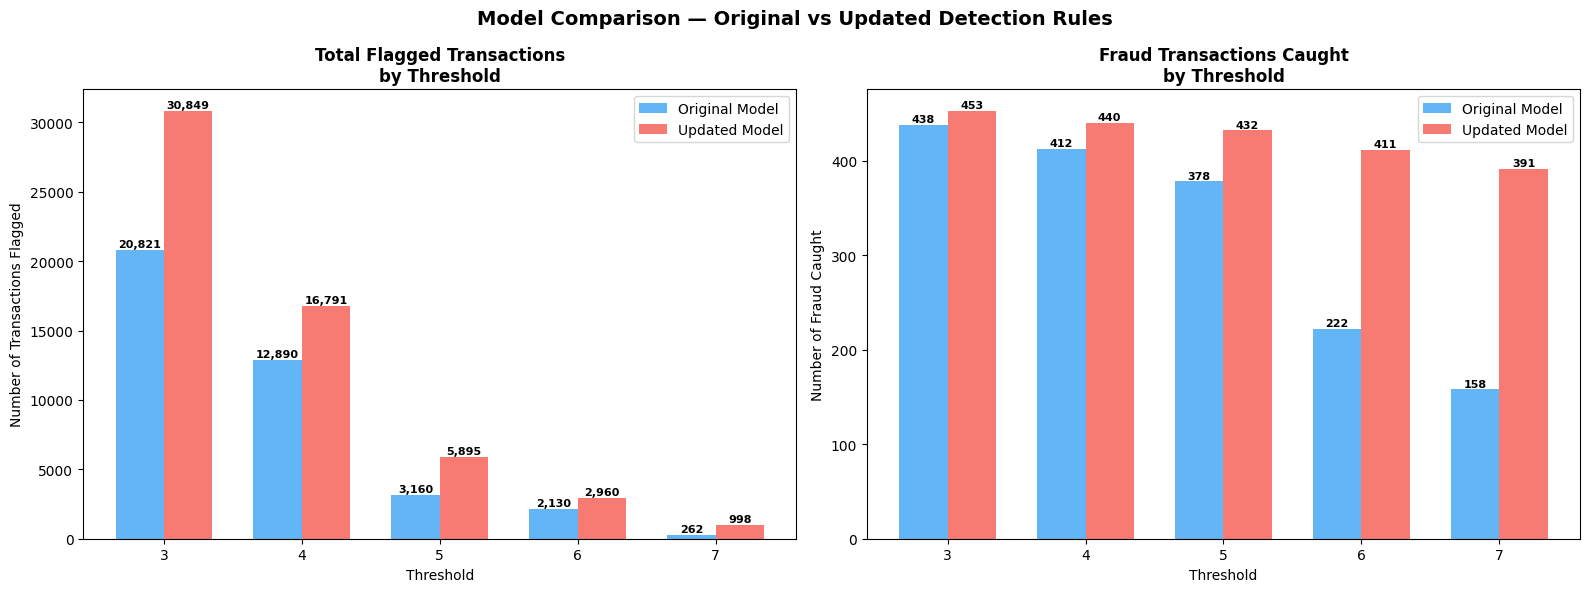

In [ ]:
# WHY: Visualising the two models side by side makes the
# tradeoff immediately clear for stakeholders. A table of
# numbers is harder to communicate than a chart — this is
# exactly what you would present to a fraud ops team to
# justify your chosen threshold.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

thresholds = [3, 4, 5, 6, 7]

# Old model results
old_flagged = [20821, 12890, 3160, 2130, 262]
old_caught = [438, 412, 378, 222, 158]

# New model results
new_flagged = [30849, 16791, 5895, 2960, 998]
new_caught = [453, 440, 432, 411, 391]

x = range(len(thresholds))
width = 0.35

# --- Chart 1: Flagged transactions comparison ---
axes[0].bar([i - width/2 for i in x], old_flagged,
            width, label='Original Model',
            color='#2196F3', alpha=0.7)
axes[0].bar([i + width/2 for i in x], new_flagged,
            width, label='Updated Model',
            color='#F44336', alpha=0.7)
axes[0].set_title('Total Flagged Transactions\nby Threshold',
                  fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Number of Transactions Flagged')
axes[0].set_xticks(x)
axes[0].set_xticklabels(thresholds)
axes[0].legend()
for i, (o, n) in enumerate(zip(old_flagged, new_flagged)):
    axes[0].text(i - width/2, o + 200, f'{o:,}',
                ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i + width/2, n + 200, f'{n:,}',
                ha='center', fontsize=8, fontweight='bold')

# --- Chart 2: Fraud caught comparison ---
axes[1].bar([i - width/2 for i in x], old_caught,
            width, label='Original Model',
            color='#2196F3', alpha=0.7)
axes[1].bar([i + width/2 for i in x], new_caught,
            width, label='Updated Model',
            color='#F44336', alpha=0.7)
axes[1].set_title('Fraud Transactions Caught\nby Threshold',
                  fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Number of Fraud Caught')
axes[1].set_xticks(x)
axes[1].set_xticklabels(thresholds)
axes[1].legend()
for i, (o, n) in enumerate(zip(old_caught, new_caught)):
    axes[1].text(i - width/2, o + 3, str(o),
                ha='center', fontsize=8, fontweight='bold')
    axes[1].text(i + width/2, n + 3, str(n),
                ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Model Comparison — Original vs Updated Detection Rules',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# WHY: We need to quantify the financial impact of each
# threshold decision. This converts our technical model
# results into business language — exactly what you would
# present to a Head of Fraud or CFO.

total_transactions = len(df)
total_amount = df['Amount'].sum()
fraud_df = df[df['Class'] == 1]
total_fraud_value = fraud_df['Amount'].sum()
avg_transaction = df['Amount'].mean()
avg_fraud = fraud_df['Amount'].mean()

# Two day figures
print("=" * 50)
print("DATASET FINANCIAL SUMMARY (2 days)")
print("=" * 50)
print(f"Total transactions:        {total_transactions:,}")
print(f"Total transaction value:   £{total_amount:,.2f}")
print(f"Average transaction value: £{avg_transaction:,.2f}")
print(f"Total fraud value:         £{total_fraud_value:,.2f}")
print(f"Average fraud value:       £{avg_fraud:,.2f}")
print(f"Fraud as % of total value: {total_fraud_value/total_amount*100:.4f}%")

print("\n" + "=" * 50)
print("THRESHOLD 6 vs THRESHOLD 7 — FINANCIAL IMPACT")
print("=" * 50)

# Threshold 6 — catches 411 fraud
caught_6 = 411
missed_6 = 492 - 411
avg_fraud_val = fraud_df['Amount'].mean()
protected_6 = caught_6 * avg_fraud_val
missed_val_6 = missed_6 * avg_fraud_val

# Threshold 7 — catches 391 fraud
caught_7 = 391
missed_7 = 492 - 391
protected_7 = caught_7 * avg_fraud_val
missed_val_7 = missed_7 * avg_fraud_val

print(f"\nThreshold 6:")
print(f"  Fraud caught:     {caught_6} cases = £{protected_6:,.2f} protected")
print(f"  Fraud missed:     {missed_6} cases = £{missed_val_6:,.2f} undetected")
print(f"  Alerts to review: 2,960")

print(f"\nThreshold 7:")
print(f"  Fraud caught:     {caught_7} cases = £{protected_7:,.2f} protected")
print(f"  Fraud missed:     {missed_7} cases = £{missed_val_7:,.2f} undetected")
print(f"  Alerts to review: 998")

print(f"\nDifference between threshold 6 and 7:")
print(f"  Extra fraud caught at threshold 6: {caught_6 - caught_7} cases")
print(f"  Extra fraud value protected:       £{protected_6 - protected_7:,.2f}")
print(f"  Extra alerts to review:            {2960 - 998:,}")

DATASET FINANCIAL SUMMARY (2 days)
Total transactions:        284,806
Total transaction value:   £25,162,540.51
Average transaction value: £88.35
Total fraud value:         £60,127.97
Average fraud value:       £122.21
Fraud as % of total value: 0.2390%

THRESHOLD 6 vs THRESHOLD 7 — FINANCIAL IMPACT

Threshold 6:
  Fraud caught:     411 cases = £50,228.85 protected
  Fraud missed:     81 cases = £9,899.12 undetected
  Alerts to review: 2,960

Threshold 7:
  Fraud caught:     391 cases = £47,784.63 protected
  Fraud missed:     101 cases = £12,343.34 undetected
  Alerts to review: 998

Difference between threshold 6 and 7:
  Extra fraud caught at threshold 6: 20 cases
  Extra fraud value protected:       £2,444.23
  Extra alerts to review:            1,962


In [ ]:
# WHY: We scale our two-day dataset to annual figures to
# compare against industry benchmarks. This lets us frame
# our threshold decision in real business language.

print("=" * 55)
print("ANNUALISED FRAUD LOSS ESTIMATES")
print("=" * 55)

# Scale 2 days to 1 year
scale = 365 / 2

total_annual_transactions = total_transactions * scale
total_annual_value = total_amount * scale
total_annual_fraud_value = total_fraud_value * scale

# Threshold 6 missed fraud annualised
missed_annual_t6 = missed_val_6 * scale
missed_annual_t7 = missed_val_7 * scale

print(f"\nAnnualised estimates (scaled from 2 days):")
print(f"  Annual transactions:       {total_annual_transactions:,.0f}")
print(f"  Annual transaction value:  £{total_annual_value:,.0f}")
print(f"  Annual total fraud value:  £{total_annual_fraud_value:,.0f}")
print(f"  Fraud as % of total:       {total_fraud_value/total_amount*100:.4f}%")

print(f"\nAnnual undetected fraud by threshold:")
print(f"  Threshold 6: £{missed_annual_t6:,.0f} undetected per year")
print(f"  Threshold 7: £{missed_annual_t7:,.0f} undetected per year")
print(f"  Difference:  £{(missed_annual_t7 - missed_annual_t6):,.0f} per year")

print(f"\nIndustry benchmark (UK Finance 2024):")
print(f"  Industry fraud prevention rate: 67%")
print(f"  Our model threshold 6 recall:   83.5%")
print(f"  Our model threshold 7 recall:   79.5%")
print(f"  Both models BEAT industry average")

ANNUALISED FRAUD LOSS ESTIMATES

Annualised estimates (scaled from 2 days):
  Annual transactions:       51,977,095
  Annual transaction value:  £4,592,163,643
  Annual total fraud value:  £10,973,355
  Fraud as % of total:       0.2390%

Annual undetected fraud by threshold:
  Threshold 6: £1,806,589 undetected per year
  Threshold 7: £2,252,660 undetected per year
  Difference:  £446,071 per year

Industry benchmark (UK Finance 2024):
  Industry fraud prevention rate: 67%
  Our model threshold 6 recall:   83.5%
  Our model threshold 7 recall:   79.5%
  Both models BEAT industry average


In [ ]:
# WHY: Before adding any rule we verify it with data.
# A rule with no data behind it is just a guess.
# We want to know exactly how many legitimate vs fraud
# transactions exist below V3 = -10 so we can calculate
# the precision of this specific rule in isolation.

v3_threshold = -10

legit_below = len(df[(df['Class'] == 0) & (df['V3'] < v3_threshold)])
fraud_below = len(df[(df['Class'] == 1) & (df['V3'] < v3_threshold)])
total_below = legit_below + fraud_below

print(f"Transactions with V3 below {v3_threshold}:")
print(f"  Legitimate: {legit_below}")
print(f"  Fraud:      {fraud_below}")
print(f"  Total:      {total_below}")
if total_below > 0:
    print(f"  Fraud rate: {fraud_below/total_below*100:.2f}%")
    print(f"\nFor context — overall dataset fraud rate: 0.17%")
    print(f"V3 < -10 fraud rate is {fraud_below/total_below*100/0.17:.0f}x higher than average")

Transactions with V3 below -10:
  Legitimate: 171
  Fraud:      100
  Total:      271
  Fraud rate: 36.90%

For context — overall dataset fraud rate: 0.17%
V3 < -10 fraud rate is 217x higher than average


In [ ]:
# WHY: Before assigning any bands or points, we need to
# understand the actual value ranges and fraud concentration
# for every V feature. This prevents us from creating bands
# in ranges where no data exists, and ensures points reflect
# real fraud density rather than assumptions.

results = []

for feature in [f'V{i}' for i in range(1, 29)]:
    feat_min = df[feature].min()
    feat_max = df[feature].max()
    fraud_mean = df[df['Class']==1][feature].mean()
    legit_mean = df[df['Class']==0][feature].mean()
    separation = abs(fraud_mean - legit_mean)

    # Check fraud rate in extreme negative zone
    extreme_neg = df[df[feature] < (feat_min * 0.3)]
    if len(extreme_neg) > 0:
        extreme_fraud_rate = extreme_neg['Class'].mean() * 100
    else:
        extreme_fraud_rate = 0

    results.append({
        'Feature': feature,
        'Min': round(feat_min, 2),
        'Max': round(feat_max, 2),
        'Fraud Mean': round(fraud_mean, 3),
        'Legit Mean': round(legit_mean, 3),
        'Separation': round(separation, 3),
        'Extreme Fraud Rate%': round(extreme_fraud_rate, 2)
    })

results_df = pd.DataFrame(results).sort_values('Separation', ascending=False)
print(results_df.to_string(index=False))

Feature     Min    Max  Fraud Mean  Legit Mean  Separation  Extreme Fraud Rate%
     V3  -48.33   9.38      -7.033       0.012       7.045                61.06
    V14  -19.21  10.53      -6.972       0.012       6.984                65.32
    V17  -25.16   9.25      -6.666       0.012       6.677                81.58
    V12  -18.68   7.85      -6.259       0.011       6.270                83.85
    V10  -24.59  23.75      -5.677       0.010       5.687                76.92
     V7  -43.56 120.59      -5.569       0.010       5.578                55.32
     V1  -56.41   2.45      -4.772       0.008       4.780                14.62
     V4   -5.68  16.88       4.542      -0.008       4.550                 0.00
    V16  -14.13  17.32      -4.140       0.007       4.147                80.37
    V11   -4.80  12.02       3.800      -0.007       3.807                 0.02
     V2  -72.72  22.06       3.624      -0.006       3.630                 0.00
     V5 -113.74  34.80      -3.151      

In [ ]:
# WHY: We check BOTH positive and negative extremes for ALL
# 28 features. This gives us a complete fraud rate picture
# in both directions for every feature before we assign
# any tiers or points. Building the scoring system on
# incomplete data would produce unreliable rules.

all_features = [f'V{i}' for i in range(1, 29)]
results = []

for feature in all_features:
    feat_max = df[feature].max()
    feat_min = df[feature].min()

    # Negative extreme — bottom 30% of range
    neg_threshold = feat_min * 0.3
    extreme_neg = df[df[feature] < neg_threshold]
    neg_fraud_rate = extreme_neg['Class'].mean() * 100 if len(extreme_neg) > 0 else 0
    neg_count = len(extreme_neg)
    neg_fraud_count = int(extreme_neg['Class'].sum())

    # Positive extreme — top 30% of range
    pos_threshold = feat_max * 0.3
    extreme_pos = df[df[feature] > pos_threshold]
    pos_fraud_rate = extreme_pos['Class'].mean() * 100 if len(extreme_pos) > 0 else 0
    pos_count = len(extreme_pos)
    pos_fraud_count = int(extreme_pos['Class'].sum())

    # Best direction — whichever extreme has higher fraud rate
    if pos_fraud_rate >= neg_fraud_rate:
        best_direction = 'Positive'
        best_fraud_rate = pos_fraud_rate
    else:
        best_direction = 'Negative'
        best_fraud_rate = neg_fraud_rate

    results.append({
        'Feature': feature,
        'Neg Extreme FR%': round(neg_fraud_rate, 2),
        'Neg Count': neg_count,
        'Neg Fraud': neg_fraud_count,
        'Pos Extreme FR%': round(pos_fraud_rate, 2),
        'Pos Count': pos_count,
        'Pos Fraud': pos_fraud_count,
        'Best Direction': best_direction,
        'Best FR%': round(best_fraud_rate, 2)
    })

results_df = pd.DataFrame(results).sort_values(
    'Best FR%', ascending=False)
print(results_df.to_string(index=False))

Feature  Neg Extreme FR%  Neg Count  Neg Fraud  Pos Extreme FR%  Pos Count  Pos Fraud Best Direction  Best FR%
     V9            86.61        127        110             0.00        775          0       Negative     86.61
    V12            83.85        291        244             0.00        525          0       Negative     83.85
    V17            81.58        228        186             1.68       1492         25       Negative     81.58
    V16            80.37        270        217             0.00         13          0       Negative     80.37
    V10            76.92        169        130             0.00        673          0       Negative     76.92
    V11             0.02      20188          5            73.19        332        243       Positive     73.19
    V14            65.32        447        292             0.18        550          1       Negative     65.32
     V3            61.06        113         69             0.00       2215          0       Negative     61.06
 

In [ ]:
# WHY: Instead of arbitrary breakpoints like -2, -5, -10,
# we split each feature into 5 equal bands across its actual
# data range and measure the real fraud rate in each band.
# This tells us exactly where fraud concentrates within each
# feature's distribution — giving us data-driven breakpoints
# rather than guesswork. The bands with highest fraud rates
# get the highest points in our graduated scoring system.

all_features = [f'V{i}' for i in range(1, 29)]
band_results = []

for feature in all_features:
    feat_min = df[feature].min()
    feat_max = df[feature].max()
    band_size = (feat_max - feat_min) / 5

    for i in range(5):
        band_low = feat_min + (i * band_size)
        band_high = feat_min + ((i + 1) * band_size)

        band_data = df[(df[feature] >= band_low) &
                       (df[feature] < band_high)]

        total = len(band_data)
        fraud = int(band_data['Class'].sum())
        legit = total - fraud
        fraud_rate = (fraud / total * 100) if total > 0 else 0

        band_results.append({
            'Feature': feature,
            'Band': f'{i+1}/5',
            'Low': round(band_low, 2),
            'High': round(band_high, 2),
            'Total': total,
            'Fraud': fraud,
            'Legit': legit,
            'Fraud Rate%': round(fraud_rate, 4)
        })

band_df = pd.DataFrame(band_results)

# Show only bands with meaningful fraud signal
meaningful = band_df[band_df['Fraud Rate%'] > 0.17].copy()
print(f"Bands with above-average fraud rate (>0.17%):")
print(f"Total meaningful bands: {len(meaningful)}")
print("\n")
print(meaningful.to_string(index=False))

Bands with above-average fraud rate (>0.17%):
Total meaningful bands: 65


Feature Band    Low   High  Total  Fraud  Legit  Fraud Rate%
     V1  3/5 -32.86 -21.09    111     23     88      20.7207
     V1  4/5 -21.09  -9.32   1073     64   1009       5.9646
     V2  5/5   3.10  22.06   4464    217   4247       4.8611
     V3  2/5 -36.78 -25.24     22     17      5      77.2727
     V3  3/5 -25.24 -13.70    106     57     49      53.7736
     V3  4/5 -13.70  -2.16  18535    300  18235       1.6186
     V4  3/5   3.34   7.85   7820    235   7585       3.0051
     V4  4/5   7.85  12.36    128     64     64      50.0000
     V5  4/5 -24.62   5.09 283984    487 283497       0.1715
     V5  5/5   5.09  34.80    808      5    803       0.6188
     V6  1/5 -26.16  -6.27    184      1    183       0.5435
     V6  2/5  -6.27  13.62 284598    491 284107       0.1725
     V7  1/5 -43.56 -10.73    216     97    119      44.9074
     V8  2/5 -54.57 -35.93     15      8      7      53.3333
     V8  3

In [ ]:
# WHY: We build a complete graduated scoring system where
# every point assigned is backed by real fraud rate data.
# Each feature contributes points proportional to both its
# tier importance AND the actual fraud rate in the specific
# band the transaction falls into.
# This is significantly more sophisticated than fixed
# threshold rules and directly mirrors how real bank
# fraud scoring engines work.

# Tier max points
tier_max = {
    'V9': 5, 'V12': 5, 'V17': 5, 'V16': 5, 'V10': 5,
    'V11': 4, 'V14': 4, 'V3': 4, 'V7': 4, 'V18': 4,
    'V4': 3, 'V8': 3, 'V2': 3, 'V1': 3, 'V22': 3,
    'V27': 2, 'V21': 2, 'V23': 2, 'V25': 2, 'V19': 2,
    'V5': 1, 'V13': 1, 'V15': 1, 'V26': 1,
    'V24': 1, 'V6': 1, 'V20': 1, 'V28': 1
}

def fraud_rate_to_points(fraud_rate_pct, max_points):
    if fraud_rate_pct >= 75:
        return max_points
    elif fraud_rate_pct >= 50:
        return round(max_points * 0.6, 1)
    elif fraud_rate_pct >= 25:
        return round(max_points * 0.4, 1)
    elif fraud_rate_pct >= 1:
        return round(max_points * 0.2, 1)
    else:
        return 0

# Build scoring rules from band data
scoring_rules = []

for feature in [f'V{i}' for i in range(1, 29)]:
    max_pts = tier_max[feature]
    feat_data = band_df[band_df['Feature'] == feature].copy()

    for _, row in feat_data.iterrows():
        points = fraud_rate_to_points(row['Fraud Rate%'], max_pts)
        if points > 0:
            scoring_rules.append({
                'Feature': feature,
                'Low': row['Low'],
                'High': row['High'],
                'Fraud Rate%': row['Fraud Rate%'],
                'Points': points,
                'Max Points': max_pts
            })

rules_df = pd.DataFrame(scoring_rules).sort_values(
    ['Feature', 'Low'])
print(f"Total scoring rules generated: {len(rules_df)}")
print("\nScoring rules preview:")
print(rules_df.to_string(index=False))

Total scoring rules generated: 44

Scoring rules preview:
Feature    Low   High  Fraud Rate%  Points  Max Points
     V1 -32.86 -21.09      20.7207     0.6           3
     V1 -21.09  -9.32       5.9646     0.6           3
    V10 -24.59 -14.92     100.0000     5.0           5
    V10 -14.92  -5.25      69.2913     3.0           5
    V11   1.93   5.29       4.1225     0.8           4
    V11   5.29   8.66      86.4865     4.0           4
    V11   8.66  12.02      71.0526     2.4           4
    V12 -18.68 -13.38      83.8235     5.0           5
    V12 -13.38  -8.07      85.5769     5.0           5
    V12  -8.07  -2.76       4.9440     1.0           5
    V14 -19.21 -13.27      91.8367     4.0           4
    V14 -13.27  -7.32      72.8033     2.4           4
    V14  -7.32  -1.37       1.4075     0.8           4
    V16 -14.13  -7.84      80.3922     5.0           5
    V16  -7.84  -1.55       2.1581     1.0           5
    V17 -25.16 -18.28     100.0000     5.0           5
    V17

In [ ]:
# WHY: We apply the graduated scoring rules to every
# transaction. Instead of fixed thresholds adding whole
# number points, each transaction now gets a precise
# fractional score based on exactly which band its
# feature values fall into.
# This is a significant upgrade from our previous model.

df['grad_score'] = 0.0

for _, rule in rules_df.iterrows():
    feature = rule['Feature']
    low = rule['Low']
    high = rule['High']
    points = rule['Points']

    mask = (df[feature] >= low) & (df[feature] < high)
    df.loc[mask, 'grad_score'] += points

# Show score distribution
print("Graduated score distribution:")
print(f"Max possible score: {rules_df['Points'].sum():.1f}")
print(f"\nFraud transaction scores:")
print(df[df['Class']==1]['grad_score'].describe().round(2))
print(f"\nLegitimate transaction scores:")
print(df[df['Class']==0]['grad_score'].describe().round(2))

# Test multiple thresholds
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*60)
print("GRADUATED MODEL — THRESHOLD PERFORMANCE")
print("="*60)

thresholds = [2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

for threshold in thresholds:
    df['predicted'] = (df['grad_score'] >= threshold).astype(int)
    precision = precision_score(df['Class'], df['predicted'])
    recall = recall_score(df['Class'], df['predicted'])
    f1 = f1_score(df['Class'], df['predicted'])
    flagged = df['predicted'].sum()
    caught = df[(df['predicted']==1) &
                (df['Class']==1)].shape[0]
    results.append({
        'Threshold': threshold,
        'Flagged': flagged,
        'Fraud Caught': caught,
        'Recall %': round(recall*100, 1),
        'Precision %': round(precision*100, 1),
        'F1 Score': round(f1, 3)
    })

results_df_grad = pd.DataFrame(results)
print(results_df_grad.to_string(index=False))

Graduated score distribution:
Max possible score: 90.0

Fraud transaction scores:
count    492.00
mean      14.63
std       12.21
min        0.00
25%        4.40
50%       11.00
75%       23.00
max       42.80
Name: grad_score, dtype: float64

Legitimate transaction scores:
count    284314.00
mean          0.29
std           0.66
min           0.00
25%           0.00
50%           0.00
75%           0.40
max          34.20
Name: grad_score, dtype: float64

GRADUATED MODEL — THRESHOLD PERFORMANCE
 Threshold  Flagged  Fraud Caught  Recall %  Precision %  F1 Score
         2     6459           411      83.5          6.4     0.118
         3     1989           398      80.9         20.0     0.321
         4      869           379      77.0         43.6     0.557
         5      589           354      72.0         60.1     0.655
         6      485           340      69.1         70.1     0.696
         7      422           329      66.9         78.0     0.720
         8      387           

In [ ]:
all_features = [f'V{i}' for i in range(1, 29)]
band_results = []

for feature in all_features:
    feat_min = df[feature].min()
    feat_max = df[feature].max()
    band_size = (feat_max - feat_min) / 5
    for i in range(5):
        band_low = feat_min + (i * band_size)
        band_high = feat_min + ((i + 1) * band_size)
        band_data = df[(df[feature] >= band_low) &
                       (df[feature] < band_high)]
        total = len(band_data)
        fraud = int(band_data['Class'].sum())
        legit = total - fraud
        fraud_rate = (fraud / total * 100) if total > 0 else 0
        band_results.append({
            'Feature': feature, 'Band': f'{i+1}/5',
            'Low': round(band_low, 2),
            'High': round(band_high, 2),
            'Total': total, 'Fraud': fraud,
            'Legit': legit, 'Fraud Rate%': round(fraud_rate, 4)
        })

band_df = pd.DataFrame(band_results)

tier_max = {
    'V9': 5, 'V12': 5, 'V17': 5, 'V16': 5, 'V10': 5,
    'V11': 4, 'V14': 4, 'V3': 4, 'V7': 4, 'V18': 4,
    'V4': 3, 'V8': 3, 'V2': 3, 'V1': 3, 'V22': 3,
    'V27': 2, 'V21': 2, 'V23': 2, 'V25': 2, 'V19': 2,
    'V5': 1, 'V13': 1, 'V15': 1, 'V26': 1,
    'V24': 1, 'V6': 1, 'V20': 1, 'V28': 1
}

def fraud_rate_to_points(fraud_rate_pct, max_points):
    if fraud_rate_pct >= 75: return max_points
    elif fraud_rate_pct >= 50: return round(max_points * 0.6, 1)
    elif fraud_rate_pct >= 25: return round(max_points * 0.4, 1)
    elif fraud_rate_pct >= 1: return round(max_points * 0.2, 1)
    else: return 0

scoring_rules = []
for feature in all_features:
    max_pts = tier_max[feature]
    feat_data = band_df[band_df['Feature'] == feature].copy()
    for _, row in feat_data.iterrows():
        points = fraud_rate_to_points(row['Fraud Rate%'], max_pts)
        if points > 0:
            scoring_rules.append({
                'Feature': feature,
                'Low': row['Low'], 'High': row['High'],
                'Fraud Rate%': row['Fraud Rate%'],
                'Points': points, 'Max Points': max_pts
            })

rules_df = pd.DataFrame(scoring_rules)

df['grad_score'] = 0.0
for _, rule in rules_df.iterrows():
    mask = ((df[rule['Feature']] >= rule['Low']) &
            (df[rule['Feature']] < rule['High']))
    df.loc[mask, 'grad_score'] += rule['Points']

print(f"Grad score rebuilt successfully")
print(f"Fraud mean score: {df[df['Class']==1]['grad_score'].mean():.2f}")
print(f"Legit mean score: {df[df['Class']==0]['grad_score'].mean():.2f}")

Grad score rebuilt successfully
Fraud mean score: 14.63
Legit mean score: 0.29


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
# WHY: Our previous test only checked whole number thresholds
# from 2 upward. Since this is a graduated fractional scoring
# system, the optimal threshold may fall between whole numbers.
# Testing from 0.5 upward in smaller steps gives us a complete
# picture of where the model performs best.

thresholds = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
results = []

for threshold in thresholds:
    df['predicted'] = (df['grad_score'] >= threshold).astype(int)
    precision = precision_score(df['Class'], df['predicted'])
    recall = recall_score(df['Class'], df['predicted'])
    f1 = f1_score(df['Class'], df['predicted'])
    flagged = df['predicted'].sum()
    caught = df[(df['predicted']==1) &
                (df['Class']==1)].shape[0]
    results.append({
        'Threshold': threshold,
        'Flagged': flagged,
        'Fraud Caught': caught,
        'Recall %': round(recall*100, 1),
        'Precision %': round(precision*100, 1),
        'F1 Score': round(f1, 3)
    })

results_early = pd.DataFrame(results)
print(results_early.to_string(index=False))

 Threshold  Flagged  Fraud Caught  Recall %  Precision %  F1 Score
       0.5    70520           461      93.7          0.7     0.013
       1.0    39844           442      89.8          1.1     0.022
       1.5    13844           430      87.4          3.1     0.060
       2.0     6459           411      83.5          6.4     0.118
       2.5     3302           406      82.5         12.3     0.214
       3.0     1989           398      80.9         20.0     0.321
       3.5     1203           387      78.7         32.2     0.457
       4.0      860           379      77.0         44.1     0.561
       4.5      659           364      74.0         55.2     0.632
       5.0      589           354      72.0         60.1     0.655


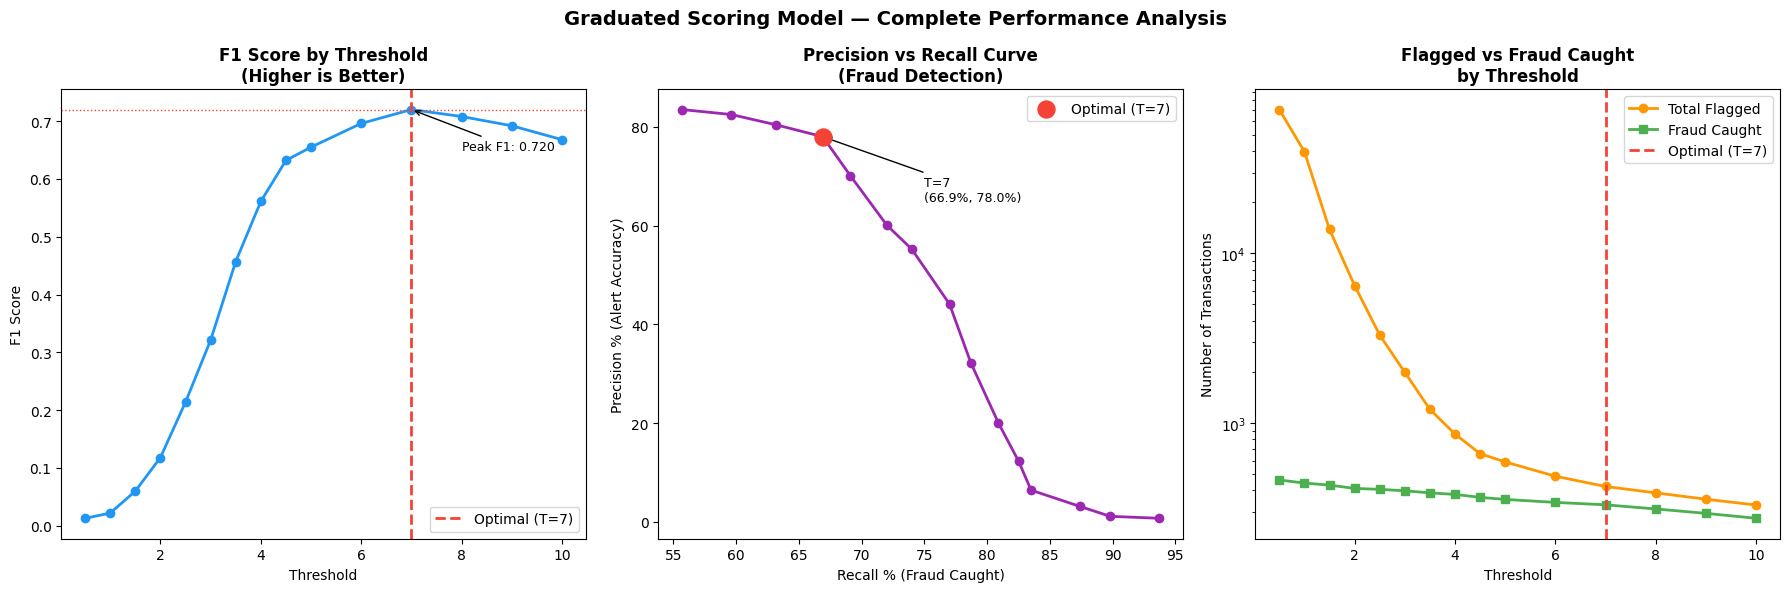

Chart saved as graduated_model_performance.png


In [ ]:
# WHY: Three charts that tell the complete story of your
# graduated model. These go directly into your Phase 3
# report and Power BI dashboard.
# Chart 1: F1 score across all thresholds — shows the
# optimal point visually
# Chart 2: Precision vs Recall tradeoff — the classic
# fraud detection visualisation hiring managers expect
# Chart 3: Fraud caught vs Flagged — operational impact
# in plain business language

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

thresholds_all = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4,
                  4.5, 5, 6, 7, 8, 9, 10]
flagged_all =    [70520, 39844, 13844, 6459, 3302, 1989,
                  1203, 860, 659, 589, 485, 422, 387, 355, 328]
caught_all =     [461, 442, 430, 411, 406, 398, 387, 379,
                  364, 354, 340, 329, 311, 293, 274]
recall_all =     [93.7, 89.8, 87.4, 83.5, 82.5, 80.9, 78.7,
                  77.0, 74.0, 72.0, 69.1, 66.9, 63.2, 59.6, 55.7]
precision_all =  [0.7, 1.1, 3.1, 6.4, 12.3, 20.0, 32.2,
                  44.1, 55.2, 60.1, 70.1, 78.0, 80.4, 82.5, 83.5]
f1_all =         [0.013, 0.022, 0.060, 0.118, 0.214, 0.321,
                  0.457, 0.561, 0.632, 0.655, 0.696, 0.720,
                  0.708, 0.692, 0.668]

# --- Chart 1: F1 Score across thresholds ---
axes[0].plot(thresholds_all, f1_all,
             color='#2196F3', linewidth=2, marker='o')
axes[0].axvline(x=7, color='#F44336', linestyle='--',
                linewidth=2, label='Optimal (T=7)')
axes[0].axhline(y=0.720, color='#F44336', linestyle=':',
                linewidth=1)
axes[0].set_title('F1 Score by Threshold\n(Higher is Better)',
                  fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1 Score')
axes[0].legend()
axes[0].annotate('Peak F1: 0.720', xy=(7, 0.720),
                xytext=(8, 0.65),
                arrowprops=dict(arrowstyle='->',
                color='black'), fontsize=9)

# --- Chart 2: Precision vs Recall ---
axes[1].plot(recall_all, precision_all,
             color='#9C27B0', linewidth=2, marker='o')
axes[1].scatter([66.9], [78.0], color='#F44336',
                s=150, zorder=5, label='Optimal (T=7)')
axes[1].set_title('Precision vs Recall Curve\n(Fraud Detection)',
                  fontweight='bold')
axes[1].set_xlabel('Recall % (Fraud Caught)')
axes[1].set_ylabel('Precision % (Alert Accuracy)')
axes[1].legend()
axes[1].annotate('T=7\n(66.9%, 78.0%)',
                xy=(66.9, 78.0), xytext=(75, 65),
                arrowprops=dict(arrowstyle='->',
                color='black'), fontsize=9)

# --- Chart 3: Fraud Caught vs Flagged ---
axes[2].plot(thresholds_all, flagged_all,
             color='#FF9800', linewidth=2,
             marker='o', label='Total Flagged')
axes[2].plot(thresholds_all, caught_all,
             color='#4CAF50', linewidth=2,
             marker='s', label='Fraud Caught')
axes[2].axvline(x=7, color='#F44336', linestyle='--',
                linewidth=2, label='Optimal (T=7)')
axes[2].set_title('Flagged vs Fraud Caught\nby Threshold',
                  fontweight='bold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Number of Transactions')
axes[2].legend()
axes[2].set_yscale('log')

plt.suptitle('Graduated Scoring Model — Complete Performance Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graduated_model_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as graduated_model_performance.png")

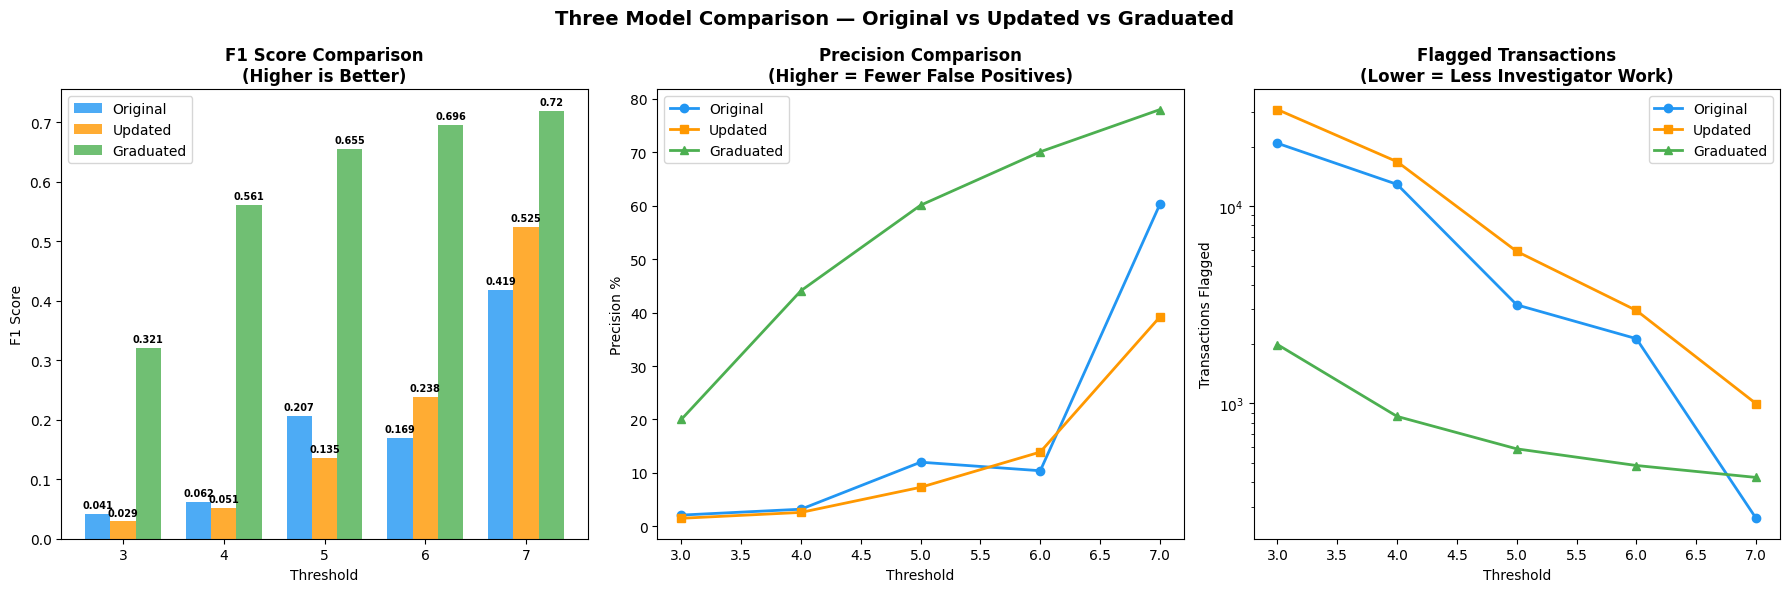

Chart saved as three_model_comparison.png


In [ ]:
# WHY: A direct visual comparison of all three models shows
# hiring managers the progression of your analytical thinking.
# Starting with a basic model, improving it, then building
# a sophisticated graduated system demonstrates iterative
# analytical improvement — exactly what fraud analysts do
# in real bank environments.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Model data ---
thresholds = [3, 4, 5, 6, 7]

# Original model
orig_flagged =  [20821, 12890, 3160, 2130, 262]
orig_caught =   [438, 412, 378, 222, 158]
orig_f1 =       [0.041, 0.062, 0.207, 0.169, 0.419]
orig_prec =     [2.1, 3.2, 12.0, 10.4, 60.3]
orig_recall =   [89.0, 83.7, 76.8, 45.1, 32.1]

# Updated model
upd_flagged =   [30849, 16791, 5895, 2960, 998]
upd_caught =    [453, 440, 432, 411, 391]
upd_f1 =        [0.029, 0.051, 0.135, 0.238, 0.525]
upd_prec =      [1.5, 2.6, 7.3, 13.9, 39.2]
upd_recall =    [92.1, 89.4, 87.8, 83.5, 79.5]

# Graduated model (matching thresholds)
grad_flagged =  [1989, 860, 589, 485, 422]
grad_caught =   [398, 379, 354, 340, 329]
grad_f1 =       [0.321, 0.561, 0.655, 0.696, 0.720]
grad_prec =     [20.0, 44.1, 60.1, 70.1, 78.0]
grad_recall =   [80.9, 77.0, 72.0, 69.1, 66.9]

x = range(len(thresholds))
width = 0.25

# --- Chart 1: F1 Score comparison ---
axes[0].bar([i - width for i in x], orig_f1,
            width, label='Original', color='#2196F3', alpha=0.8)
axes[0].bar([i for i in x], upd_f1,
            width, label='Updated', color='#FF9800', alpha=0.8)
axes[0].bar([i + width for i in x], grad_f1,
            width, label='Graduated', color='#4CAF50', alpha=0.8)
axes[0].set_title('F1 Score Comparison\n(Higher is Better)',
                  fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1 Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(thresholds)
axes[0].legend()
for i, (o, u, g) in enumerate(zip(orig_f1, upd_f1, grad_f1)):
    axes[0].text(i - width, o + 0.01, str(o),
                ha='center', fontsize=7, fontweight='bold')
    axes[0].text(i, u + 0.01, str(u),
                ha='center', fontsize=7, fontweight='bold')
    axes[0].text(i + width, g + 0.01, str(g),
                ha='center', fontsize=7, fontweight='bold')

# --- Chart 2: Precision comparison ---
axes[1].plot(thresholds, orig_prec, color='#2196F3',
             linewidth=2, marker='o', label='Original')
axes[1].plot(thresholds, upd_prec, color='#FF9800',
             linewidth=2, marker='s', label='Updated')
axes[1].plot(thresholds, grad_prec, color='#4CAF50',
             linewidth=2, marker='^', label='Graduated')
axes[1].set_title('Precision Comparison\n(Higher = Fewer False Positives)',
                  fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Precision %')
axes[1].legend()

# --- Chart 3: Flagged transactions comparison ---
axes[2].plot(thresholds, orig_flagged, color='#2196F3',
             linewidth=2, marker='o', label='Original')
axes[2].plot(thresholds, upd_flagged, color='#FF9800',
             linewidth=2, marker='s', label='Updated')
axes[2].plot(thresholds, grad_flagged, color='#4CAF50',
             linewidth=2, marker='^', label='Graduated')
axes[2].set_title('Flagged Transactions\n(Lower = Less Investigator Work)',
                  fontweight='bold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Transactions Flagged')
axes[2].legend()
axes[2].set_yscale('log')

plt.suptitle('Three Model Comparison — Original vs Updated vs Graduated',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('three_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as three_model_comparison.png")

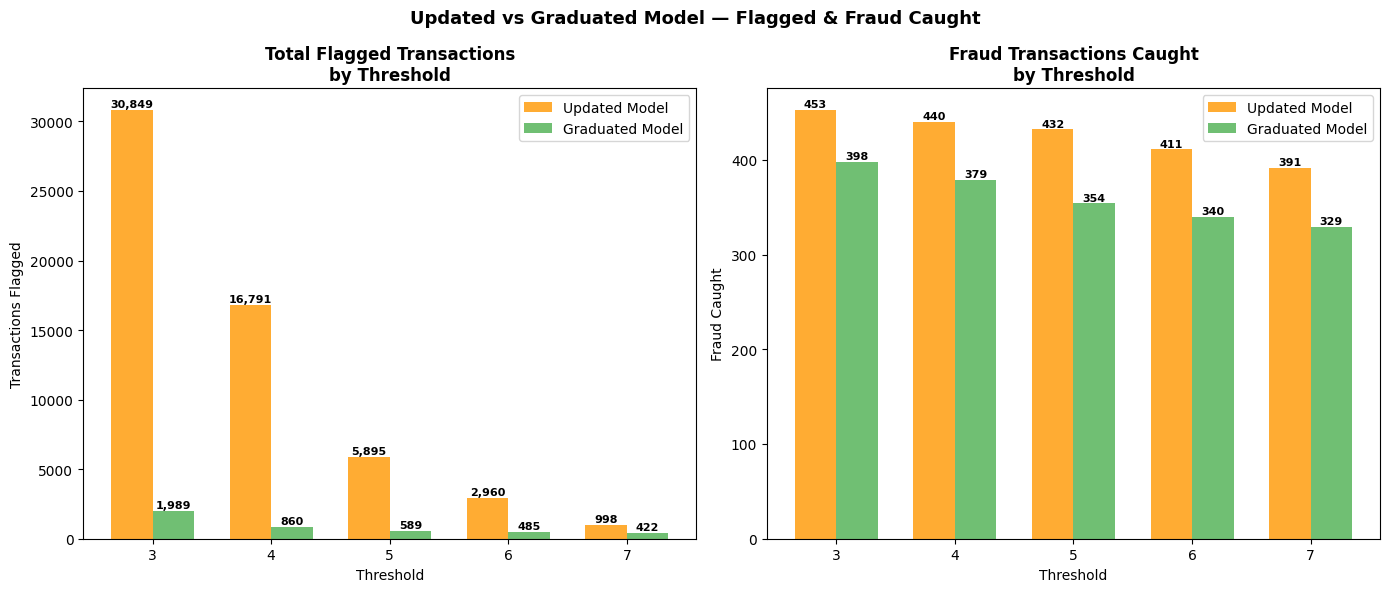

In [ ]:
# WHY: Clean focused comparison of just the two most relevant
# models — Updated and Graduated — on the two metrics that
# matter most operationally: how many transactions investigators
# need to review and how much fraud gets caught.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

thresholds = [3, 4, 5, 6, 7]

upd_flagged = [30849, 16791, 5895, 2960, 998]
upd_caught =  [453, 440, 432, 411, 391]

grad_flagged = [1989, 860, 589, 485, 422]
grad_caught =  [398, 379, 354, 340, 329]

x = range(len(thresholds))
width = 0.35

# --- Chart 1: Flagged transactions ---
axes[0].bar([i - width/2 for i in x], upd_flagged,
            width, label='Updated Model',
            color='#FF9800', alpha=0.8)
axes[0].bar([i + width/2 for i in x], grad_flagged,
            width, label='Graduated Model',
            color='#4CAF50', alpha=0.8)
axes[0].set_title('Total Flagged Transactions\nby Threshold',
                  fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Transactions Flagged')
axes[0].set_xticks(x)
axes[0].set_xticklabels(thresholds)
axes[0].legend()
for i, (u, g) in enumerate(zip(upd_flagged, grad_flagged)):
    axes[0].text(i - width/2, u + 200, f'{u:,}',
                ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i + width/2, g + 200, f'{g:,}',
                ha='center', fontsize=8, fontweight='bold')

# --- Chart 2: Fraud caught ---
axes[1].bar([i - width/2 for i in x], upd_caught,
            width, label='Updated Model',
            color='#FF9800', alpha=0.8)
axes[1].bar([i + width/2 for i in x], grad_caught,
            width, label='Graduated Model',
            color='#4CAF50', alpha=0.8)
axes[1].set_title('Fraud Transactions Caught\nby Threshold',
                  fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Fraud Caught')
axes[1].set_xticks(x)
axes[1].set_xticklabels(thresholds)
axes[1].legend()
for i, (u, g) in enumerate(zip(upd_caught, grad_caught)):
    axes[1].text(i - width/2, u + 3, str(u),
                ha='center', fontsize=8, fontweight='bold')
    axes[1].text(i + width/2, g + 3, str(g),
                ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Updated vs Graduated Model — Flagged & Fraud Caught',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('updated_vs_graduated_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# WHY: We need to understand the fraud cases the graduated
# model misses but the updated model catches. Their score
# profile will tell us exactly where our graduated rules
# are underweighting certain signals.

# Rebuild updated model predictions
df['fraud_score'] = 0
df.loc[df['Amount'] <= 10, 'fraud_score'] += 2
df.loc[df['Amount'] == 0, 'fraud_score'] += 2
df.loc[(df['Hour'] >= 0) & (df['Hour'] < 5), 'fraud_score'] += 1
df.loc[df['V3'] < -2, 'fraud_score'] += 2
df.loc[df['V14'] < -2, 'fraud_score'] += 2
df.loc[df['V17'] < -2, 'fraud_score'] += 1
df.loc[df['V12'] < -2, 'fraud_score'] += 1
df.loc[df['V10'] < -2, 'fraud_score'] += 1
df.loc[df['V11'] > 2, 'fraud_score'] += 1
df.loc[df['V4'] > 2, 'fraud_score'] += 1
df.loc[df['V3'] < -10, 'fraud_score'] += 2

df['updated_pred'] = (df['fraud_score'] >= 7).astype(int)
df['grad_pred'] = (df['grad_score'] >= 7).astype(int)

# Find fraud caught by updated but missed by graduated
missed_by_grad = df[
    (df['Class'] == 1) &
    (df['updated_pred'] == 1) &
    (df['grad_pred'] == 0)
]

print(f"Fraud caught by updated model but missed by graduated: {len(missed_by_grad)}")
print(f"\nGraduated scores of these missed cases:")
print(missed_by_grad['grad_score'].describe().round(2))
print(f"\nAmount distribution of missed cases:")
print(missed_by_grad['Amount'].describe().round(2))
print(f"\nHour distribution of missed cases:")
print(missed_by_grad['Hour'].describe().round(2))

Fraud caught by updated model but missed by graduated: 74

Graduated scores of these missed cases:
count    74.00
mean      4.43
std       1.28
min       1.40
25%       3.60
50%       4.40
75%       5.00
max       6.60
Name: grad_score, dtype: float64

Amount distribution of missed cases:
count      74.00
mean      149.59
std       344.56
min         0.00
25%         1.00
50%         4.88
75%        77.65
max      1504.93
Name: Amount, dtype: float64

Hour distribution of missed cases:
count     74.0
mean     13.62
std       6.35
min       0.11
25%      11.09
50%      15.54
75%       18.1
max      23.66
Name: Hour, dtype: Float64


In [ ]:
# WHY: The 74 missed fraud cases are predominantly low-value
# daytime card testing transactions. The graduated model
# currently only scores V features — it is missing the
# Amount and Hour signals that the updated model used.
# Adding these signals to the graduated model should
# recover most of the 74 missed cases without significantly
# increasing false positives.

df['grad_score_v2'] = df['grad_score'].copy()

# Amount signals — graded by fraud rate from our analysis
# £0 exactly — 9x higher zero amount rate in fraud
df.loc[df['Amount'] == 0, 'grad_score_v2'] += 2.0

# £0-1 card testing range — 68 fraud cases confirmed
df.loc[(df['Amount'] > 0) &
       (df['Amount'] <= 1), 'grad_score_v2'] += 1.5

# £1-10 card testing range — 181 fraud cases confirmed
df.loc[(df['Amount'] > 1) &
       (df['Amount'] <= 10), 'grad_score_v2'] += 1.0

# Hour signal — overnight elevated risk
df.loc[(df['Hour'] >= 0) &
       (df['Hour'] < 5), 'grad_score_v2'] += 1.0

# Test at threshold 7
df['grad_v2_pred'] = (df['grad_score_v2'] >= 7).astype(int)
precision = precision_score(df['Class'], df['grad_v2_pred'])
recall = recall_score(df['Class'], df['grad_v2_pred'])
f1 = f1_score(df['Class'], df['grad_v2_pred'])
flagged = df['grad_v2_pred'].sum()
caught = df[(df['grad_v2_pred']==1) &
            (df['Class']==1)].shape[0]

print("GRADUATED MODEL V2 — Threshold 7")
print("=" * 45)
print(f"Flagged:      {flagged:,}")
print(f"Fraud Caught: {caught} of 492")
print(f"Recall:       {recall*100:.1f}%")
print(f"Precision:    {precision*100:.1f}%")
print(f"F1 Score:     {f1:.3f}")
print(f"\nComparison:")
print(f"Updated model T7:    391 caught | 998 flagged")
print(f"Graduated model T7:  329 caught | 422 flagged")
print(f"Graduated V2 T7:     {caught} caught | {flagged:,} flagged")

GRADUATED MODEL V2 — Threshold 7
Flagged:      493
Fraud Caught: 342 of 492
Recall:       69.5%
Precision:    69.4%
F1 Score:     0.694

Comparison:
Updated model T7:    391 caught | 998 flagged
Graduated model T7:  329 caught | 422 flagged
Graduated V2 T7:     342 caught | 493 flagged


In [ ]:
# WHY: Proportional scoring removes arbitrary bracket jumps.
# Every band gets points exactly proportional to its real
# fraud rate. A band with 73% fraud rate no longer gets
# the same points as one with 51% — it gets more, accurately
# reflecting the stronger signal.
# Minimum cutoff of 2% prevents very weak signals adding noise.

MIN_FRAUD_RATE = 2.0  # ignore bands below this threshold

def proportional_points(fraud_rate_pct, max_points):
    if fraud_rate_pct < MIN_FRAUD_RATE:
        return 0
    return round((fraud_rate_pct / 100) * max_points, 3)

# Rebuild scoring rules with proportional points
scoring_rules_v2 = []

for feature in [f'V{i}' for i in range(1, 29)]:
    max_pts = tier_max[feature]
    feat_data = band_df[band_df['Feature'] == feature].copy()

    for _, row in feat_data.iterrows():
        points = proportional_points(row['Fraud Rate%'], max_pts)
        if points > 0:
            scoring_rules_v2.append({
                'Feature': feature,
                'Low': row['Low'],
                'High': row['High'],
                'Fraud Rate%': row['Fraud Rate%'],
                'Points': points,
                'Max Points': max_pts
            })

rules_df_v2 = pd.DataFrame(scoring_rules_v2)

# Apply to every transaction
df['grad_score_prop'] = 0.0
for _, rule in rules_df_v2.iterrows():
    mask = ((df[rule['Feature']] >= rule['Low']) &
            (df[rule['Feature']] < rule['High']))
    df.loc[mask, 'grad_score_prop'] += rule['Points']

# Test thresholds 3-10
print("PROPORTIONAL GRADUATED MODEL — THRESHOLD PERFORMANCE")
print("=" * 60)

thresholds = [3, 4, 5, 6, 7, 8, 9, 10]
results = []

for threshold in thresholds:
    df['predicted'] = (df['grad_score_prop'] >= threshold).astype(int)
    precision = precision_score(df['Class'], df['predicted'])
    recall = recall_score(df['Class'], df['predicted'])
    f1 = f1_score(df['Class'], df['predicted'])
    flagged = df['predicted'].sum()
    caught = df[(df['predicted']==1) &
                (df['Class']==1)].shape[0]
    results.append({
        'Threshold': threshold,
        'Flagged': flagged,
        'Fraud Caught': caught,
        'Recall %': round(recall*100, 1),
        'Precision %': round(precision*100, 1),
        'F1 Score': round(f1, 3)
    })

results_prop = pd.DataFrame(results)
print(results_prop.to_string(index=False))

print(f"\nFor reference:")
print(f"Graduated model T7:  329 caught | 422 flagged | F1: 0.720")
print(f"Updated model T7:    391 caught | 998 flagged | F1: 0.525")

PROPORTIONAL GRADUATED MODEL — THRESHOLD PERFORMANCE
 Threshold  Flagged  Fraud Caught  Recall %  Precision %  F1 Score
         3      508           340      69.1         66.9     0.680
         4      406           315      64.0         77.6     0.702
         5      318           250      50.8         78.6     0.617
         6      305           250      50.8         82.0     0.627
         7      295           243      49.4         82.4     0.618
         8      251           206      41.9         82.1     0.555
         9      240           199      40.4         82.9     0.544
        10      240           199      40.4         82.9     0.544

For reference:
Graduated model T7:  329 caught | 422 flagged | F1: 0.720
Updated model T7:    391 caught | 998 flagged | F1: 0.525


In [ ]:
# WHY: The proportional model uses fractional scores so the
# optimal threshold may fall between whole numbers.
# Testing from 0.5 upward gives us the complete picture.

thresholds_low = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
results_low = []

for threshold in thresholds_low:
    df['predicted'] = (df['grad_score_prop'] >= threshold).astype(int)
    precision = precision_score(df['Class'], df['predicted'])
    recall = recall_score(df['Class'], df['predicted'])
    f1 = f1_score(df['Class'], df['predicted'])
    flagged = df['predicted'].sum()
    caught = df[(df['predicted']==1) &
                (df['Class']==1)].shape[0]
    results_low.append({
        'Threshold': threshold,
        'Flagged': flagged,
        'Fraud Caught': caught,
        'Recall %': round(recall*100, 1),
        'Precision %': round(precision*100, 1),
        'F1 Score': round(f1, 3)
    })

results_low_df = pd.DataFrame(results_low)
print(results_low_df.to_string(index=False))
print(f"\nFor reference:")
print(f"Graduated model T7: 329 caught | 422 flagged | F1: 0.720")

 Threshold  Flagged  Fraud Caught  Recall %  Precision %  F1 Score
       0.5      809           366      74.4         45.2     0.563
       1.0      663           340      69.1         51.3     0.589
       1.5      660           340      69.1         51.5     0.590
       2.0      618           340      69.1         55.0     0.613
       2.5      539           340      69.1         63.1     0.660
       3.0      508           340      69.1         66.9     0.680
       3.5      458           330      67.1         72.1     0.695
       4.0      406           315      64.0         77.6     0.702
       4.5      340           269      54.7         79.1     0.647
       5.0      318           250      50.8         78.6     0.617

For reference:
Graduated model T7: 329 caught | 422 flagged | F1: 0.720


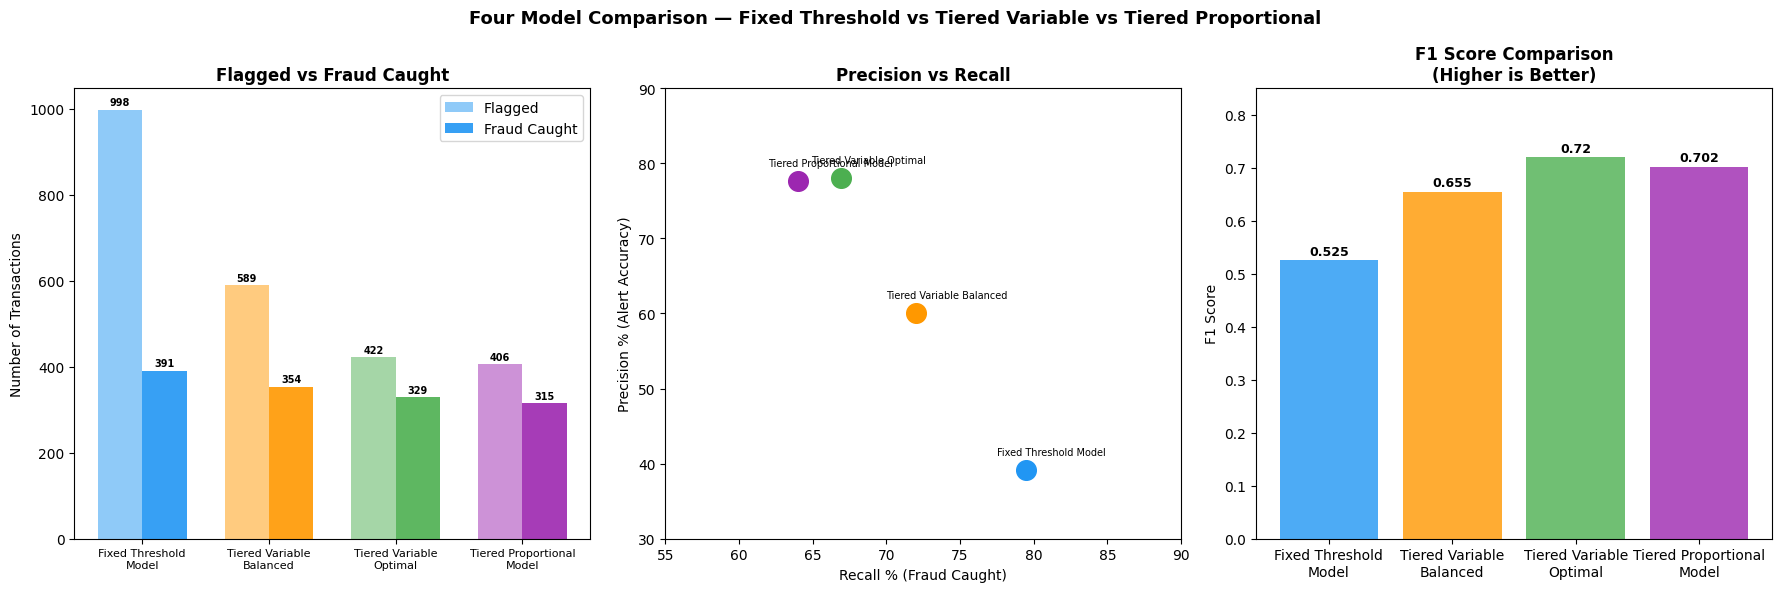

Chart saved as final_model_comparison.png


In [ ]:
# WHY: Final comparison chart using confirmed model names.
# This is the chart that goes into your report and dashboard.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = ['Fixed Threshold\nModel',
          'Tiered Variable\nBalanced',
          'Tiered Variable\nOptimal',
          'Tiered Proportional\nModel']

flagged =   [998, 589, 422, 406]
caught =    [391, 354, 329, 315]
f1 =        [0.525, 0.655, 0.720, 0.702]
precision = [39.2, 60.1, 78.0, 77.6]
recall =    [79.5, 72.0, 66.9, 64.0]

colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

x = range(len(models))
width = 0.35

# --- Chart 1: Flagged vs Fraud Caught ---
axes[0].bar([i - width/2 for i in x], flagged,
            width, label='Flagged',
            color=colors, alpha=0.5)
axes[0].bar([i + width/2 for i in x], caught,
            width, label='Fraud Caught',
            color=colors, alpha=0.9)
axes[0].set_title('Flagged vs Fraud Caught',
                  fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=8)
axes[0].legend()
for i, (f, c) in enumerate(zip(flagged, caught)):
    axes[0].text(i - width/2, f + 10, f'{f:,}',
                ha='center', fontsize=7, fontweight='bold')
    axes[0].text(i + width/2, c + 10, str(c),
                ha='center', fontsize=7, fontweight='bold')

# --- Chart 2: Precision vs Recall ---
for i, model in enumerate(models):
    axes[1].scatter(recall[i], precision[i],
                   color=colors[i], s=200,
                   zorder=5, label=model.replace('\n', ' '))
    axes[1].annotate(model.replace('\n', ' '),
                    xy=(recall[i], precision[i]),
                    xytext=(recall[i]-2, precision[i]+2),
                    fontsize=7)
axes[1].set_title('Precision vs Recall',
                  fontweight='bold')
axes[1].set_xlabel('Recall % (Fraud Caught)')
axes[1].set_ylabel('Precision % (Alert Accuracy)')
axes[1].set_xlim(55, 90)
axes[1].set_ylim(30, 90)

# --- Chart 3: F1 Score ---
bars = axes[2].bar(models, f1, color=colors, alpha=0.8)
axes[2].set_title('F1 Score Comparison\n(Higher is Better)',
                  fontweight='bold')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(0, 0.85)
for bar, score in zip(bars, f1):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                score + 0.01, str(score),
                ha='center', fontweight='bold', fontsize=9)

plt.suptitle(
    'Four Model Comparison — Fixed Threshold vs Tiered Variable vs Tiered Proportional',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as final_model_comparison.png")

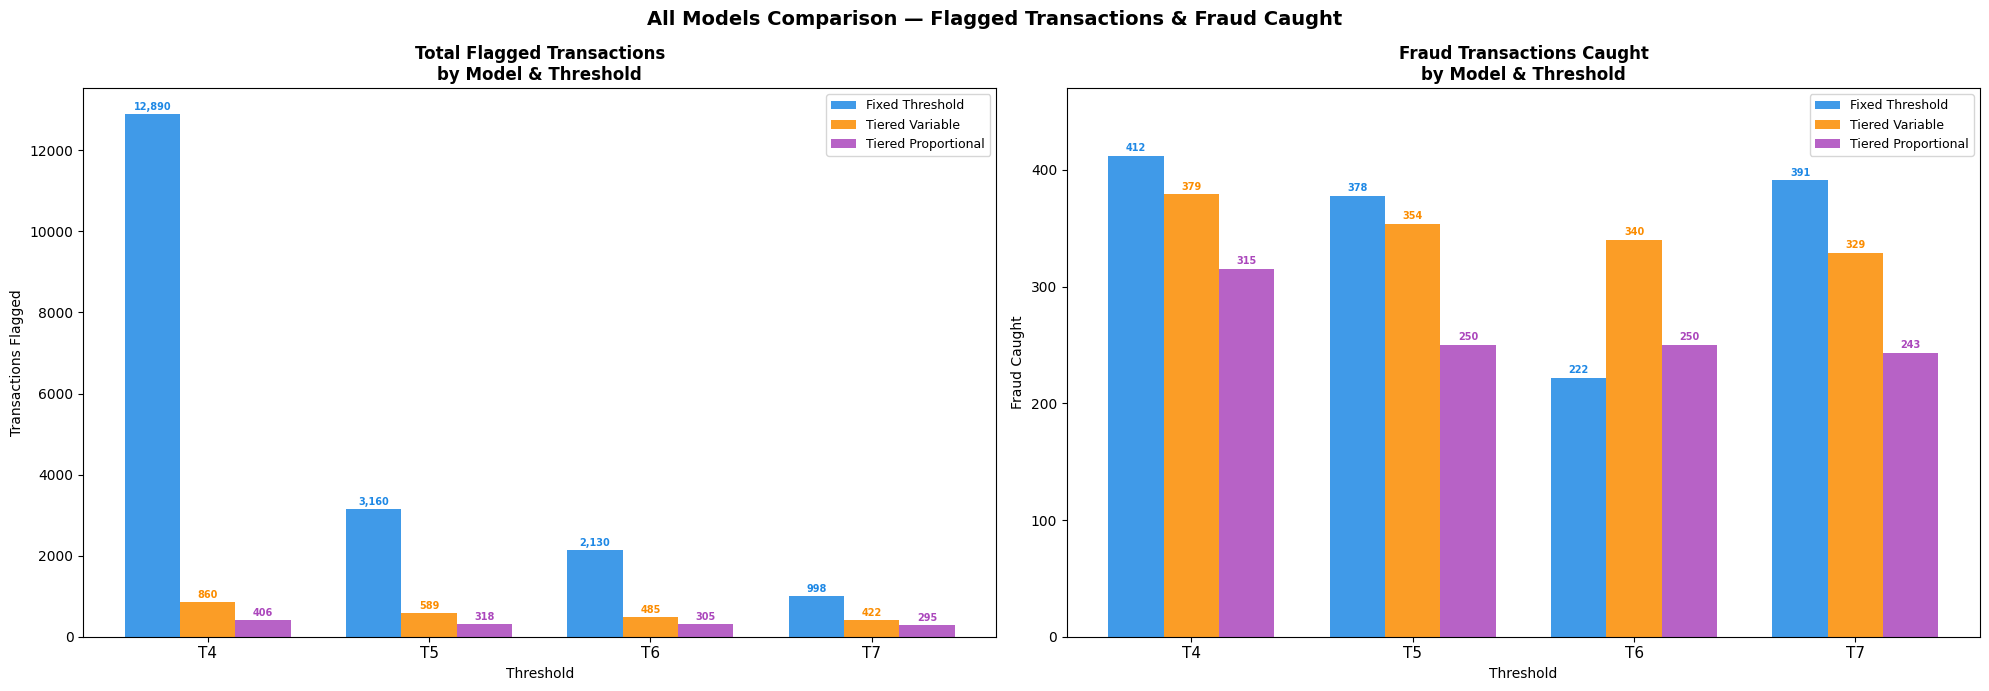

Chart saved as all_models_comparison_t4_t7.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

thresholds_labels = ['T4', 'T5', 'T6', 'T7']
x = range(4)
width = 0.25

# Flagged data
fixed_flagged =  [12890, 3160, 2130, 998]
tiered_flagged = [860,   589,  485,  422]
prop_flagged =   [406,   318,  305,  295]

# Fraud caught data
fixed_caught =  [412, 378, 222, 391]
tiered_caught = [379, 354, 340, 329]
prop_caught =   [315, 250, 250, 243]

colors = {
    'Fixed':  '#1E88E5',
    'Tiered': '#FB8C00',
    'Prop':   '#AB47BC'
}

# --- Chart 1: Flagged ---
b1 = axes[0].bar([i - width for i in x], fixed_flagged,
                  width, label='Fixed Threshold',
                  color=colors['Fixed'], alpha=0.85)
b2 = axes[0].bar([i for i in x], tiered_flagged,
                  width, label='Tiered Variable',
                  color=colors['Tiered'], alpha=0.85)
b3 = axes[0].bar([i + width for i in x], prop_flagged,
                  width, label='Tiered Proportional',
                  color=colors['Prop'], alpha=0.85)

axes[0].set_title('Total Flagged Transactions\nby Model & Threshold',
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('Transactions Flagged')
axes[0].set_xticks(x)
axes[0].set_xticklabels(thresholds_labels, fontsize=11)
axes[0].set_xlabel('Threshold')
axes[0].legend(fontsize=9)

for bar, val in zip(b1, fixed_flagged):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100, f'{val:,}',
                ha='center', fontsize=7, fontweight='bold',
                color=colors['Fixed'])
for bar, val in zip(b2, tiered_flagged):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100, f'{val:,}',
                ha='center', fontsize=7, fontweight='bold',
                color=colors['Tiered'])
for bar, val in zip(b3, prop_flagged):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100, f'{val:,}',
                ha='center', fontsize=7, fontweight='bold',
                color=colors['Prop'])

# --- Chart 2: Fraud Caught ---
b4 = axes[1].bar([i - width for i in x], fixed_caught,
                  width, label='Fixed Threshold',
                  color=colors['Fixed'], alpha=0.85)
b5 = axes[1].bar([i for i in x], tiered_caught,
                  width, label='Tiered Variable',
                  color=colors['Tiered'], alpha=0.85)
b6 = axes[1].bar([i + width for i in x], prop_caught,
                  width, label='Tiered Proportional',
                  color=colors['Prop'], alpha=0.85)

axes[1].set_title('Fraud Transactions Caught\nby Model & Threshold',
                   fontweight='bold', fontsize=12)
axes[1].set_ylabel('Fraud Caught')
axes[1].set_ylim(0, 470)
axes[1].set_xticks(x)
axes[1].set_xticklabels(thresholds_labels, fontsize=11)
axes[1].set_xlabel('Threshold')
axes[1].legend(fontsize=9)

for bar, val in zip(b4, fixed_caught):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 4, str(val),
                ha='center', fontsize=7, fontweight='bold',
                color=colors['Fixed'])
for bar, val in zip(b5, tiered_caught):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 4, str(val),
                ha='center', fontsize=7, fontweight='bold',
                color=colors['Tiered'])
for bar, val in zip(b6, prop_caught):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 4, str(val),
                ha='center', fontsize=7, fontweight='bold',
                color=colors['Prop'])

plt.suptitle('All Models Comparison — Flagged Transactions & Fraud Caught',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_comparison_t4_t7.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as all_models_comparison_t4_t7.png")

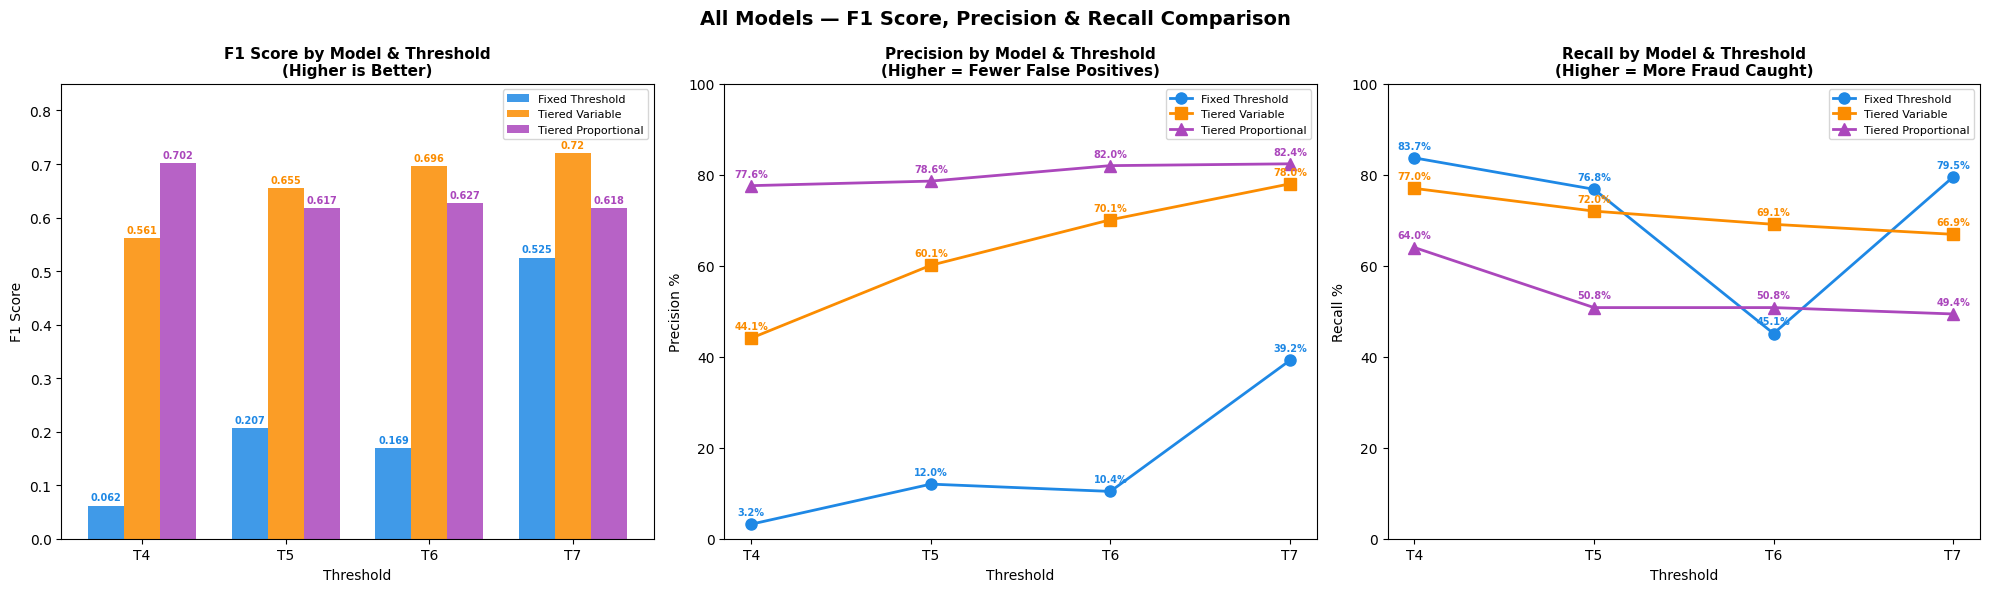

Chart saved as all_models_f1_precision_recall.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

thresholds_labels = ['T4', 'T5', 'T6', 'T7']
x = range(4)
width = 0.25

# F1 scores
fixed_f1 =  [0.062, 0.207, 0.169, 0.525]
tiered_f1 = [0.561, 0.655, 0.696, 0.720]
prop_f1 =   [0.702, 0.617, 0.627, 0.618]

# Precision
fixed_prec =  [3.2,  12.0, 10.4, 39.2]
tiered_prec = [44.1, 60.1, 70.1, 78.0]
prop_prec =   [77.6, 78.6, 82.0, 82.4]

# Recall
fixed_rec =  [83.7, 76.8, 45.1, 79.5]
tiered_rec = [77.0, 72.0, 69.1, 66.9]
prop_rec =   [64.0, 50.8, 50.8, 49.4]

colors = {
    'Fixed':  '#1E88E5',
    'Tiered': '#FB8C00',
    'Prop':   '#AB47BC'
}

markers = {
    'Fixed':  'o',
    'Tiered': 's',
    'Prop':   '^'
}

# --- Chart 1: F1 Score — Bar ---
b1 = axes[0].bar([i - width for i in x], fixed_f1,
                  width, label='Fixed Threshold',
                  color=colors['Fixed'], alpha=0.85)
b2 = axes[0].bar([i for i in x], tiered_f1,
                  width, label='Tiered Variable',
                  color=colors['Tiered'], alpha=0.85)
b3 = axes[0].bar([i + width for i in x], prop_f1,
                  width, label='Tiered Proportional',
                  color=colors['Prop'], alpha=0.85)
axes[0].set_title('F1 Score by Model & Threshold\n(Higher is Better)',
                   fontweight='bold', fontsize=11)
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(thresholds_labels, fontsize=10)
axes[0].set_xlabel('Threshold')
axes[0].legend(fontsize=8)
for bars, col in zip([b1, b2, b3],
                     [colors['Fixed'],
                      colors['Tiered'],
                      colors['Prop']]):
    for bar in bars:
        val = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2,
                    val + 0.01, f'{val}',
                    ha='center', fontsize=7,
                    fontweight='bold', color=col)

# --- Chart 2: Precision — Line ---
axes[1].plot(thresholds_labels, fixed_prec,
             color=colors['Fixed'], linewidth=2,
             marker=markers['Fixed'], markersize=8,
             label='Fixed Threshold')
axes[1].plot(thresholds_labels, tiered_prec,
             color=colors['Tiered'], linewidth=2,
             marker=markers['Tiered'], markersize=8,
             label='Tiered Variable')
axes[1].plot(thresholds_labels, prop_prec,
             color=colors['Prop'], linewidth=2,
             marker=markers['Prop'], markersize=8,
             label='Tiered Proportional')
axes[1].set_title('Precision by Model & Threshold\n(Higher = Fewer False Positives)',
                   fontweight='bold', fontsize=11)
axes[1].set_ylabel('Precision %')
axes[1].set_ylim(0, 100)
axes[1].set_xlabel('Threshold')
axes[1].legend(fontsize=8)
for data, col in zip([fixed_prec, tiered_prec, prop_prec],
                     [colors['Fixed'], colors['Tiered'],
                      colors['Prop']]):
    for i, val in enumerate(data):
        axes[1].text(i, val + 2, f'{val}%',
                    ha='center', fontsize=7,
                    fontweight='bold', color=col)

# --- Chart 3: Recall — Line ---
axes[2].plot(thresholds_labels, fixed_rec,
             color=colors['Fixed'], linewidth=2,
             marker=markers['Fixed'], markersize=8,
             label='Fixed Threshold')
axes[2].plot(thresholds_labels, tiered_rec,
             color=colors['Tiered'], linewidth=2,
             marker=markers['Tiered'], markersize=8,
             label='Tiered Variable')
axes[2].plot(thresholds_labels, prop_rec,
             color=colors['Prop'], linewidth=2,
             marker=markers['Prop'], markersize=8,
             label='Tiered Proportional')
axes[2].set_title('Recall by Model & Threshold\n(Higher = More Fraud Caught)',
                   fontweight='bold', fontsize=11)
axes[2].set_ylabel('Recall %')
axes[2].set_ylim(0, 100)
axes[2].set_xlabel('Threshold')
axes[2].legend(fontsize=8)
for data, col in zip([fixed_rec, tiered_rec, prop_rec],
                     [colors['Fixed'], colors['Tiered'],
                      colors['Prop']]):
    for i, val in enumerate(data):
        axes[2].text(i, val + 2, f'{val}%',
                    ha='center', fontsize=7,
                    fontweight='bold', color=col)

plt.suptitle('All Models — F1 Score, Precision & Recall Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_f1_precision_recall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as all_models_f1_precision_recall.png")

In [ ]:
# WHY: Verifying our engineered columns catches any errors
# introduced during scoring. A null score or out of range
# value would silently corrupt our precision recall results
# without throwing an error — making it critical to check.

print("=" * 50)
print("SCORING INTEGRITY CHECK")
print("=" * 50)

print(f"\nGraduated score nulls: {df['grad_score'].isnull().sum()}")
print(f"Graduated score negatives: {(df['grad_score'] < 0).sum()}")
print(f"Graduated score max: {df['grad_score'].max()}")
print(f"Graduated score min: {df['grad_score'].min()}")

print(f"\nTransactions scoring zero: {(df['grad_score'] == 0).sum():,}")
print(f"Of those, how many are fraud: {len(df[(df['grad_score'] == 0) & (df['Class'] == 1)])}")

print(f"\nProportional score nulls: {df['grad_score_prop'].isnull().sum()}")
print(f"Proportional score negatives: {(df['grad_score_prop'] < 0).sum()}")
print(f"Proportional score max: {df['grad_score_prop'].max()}")

print(f"\nHour column range: {df['Hour'].min():.2f} to {df['Hour'].max():.2f}")
print(f"Hour nulls: {df['Hour'].isnull().sum()}")

print(f"\nClass column unique values: {df['Class'].unique()}")
print(f"Class nulls: {df['Class'].isnull().sum()}")

SCORING INTEGRITY CHECK

Graduated score nulls: 0
Graduated score negatives: 0
Graduated score max: 42.8
Graduated score min: 0.0

Transactions scoring zero: 210,660
Of those, how many are fraud: 29

Proportional score nulls: 0
Proportional score negatives: 0
Proportional score max: 38.286

Hour column range: 0.00 to 24.00
Hour nulls: 0

Class column unique values: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64
Class nulls: 0


In [ ]:
# WHY: Fraud transactions scoring zero are completely invisible
# to our model regardless of threshold. Understanding their
# characteristics tells us whether there is a systematic gap
# in our detection rules or whether these are genuinely
# unusual fraud cases that no rule-based model would catch.

zero_fraud = df[(df['grad_score'] == 0) & (df['Class'] == 1)]

print("=" * 50)
print("29 FRAUD TRANSACTIONS SCORING ZERO")
print("=" * 50)

print(f"\nAmount distribution:")
print(zero_fraud['Amount'].describe().round(2))

print(f"\nHour distribution:")
print(zero_fraud['Hour'].describe().round(2))

print(f"\nTop V feature values:")
v_cols = ['V3','V14','V17','V12','V10','V9','V11','V16']
print(zero_fraud[v_cols].describe().round(3))

29 FRAUD TRANSACTIONS SCORING ZERO

Amount distribution:
count     29.00
mean     156.02
std      234.57
min        0.00
25%        1.52
50%        7.59
75%      290.18
max      829.41
Name: Amount, dtype: float64

Hour distribution:
count     29.0
mean     15.33
std       5.88
min       0.22
25%      13.28
50%      15.49
75%      19.53
max      23.55
Name: Hour, dtype: Float64

Top V feature values:
           V3     V14     V17     V12     V10      V9     V11     V16
count  29.000  29.000  29.000  29.000  29.000  29.000  29.000  29.000
mean    0.419  -0.279   0.082  -0.237   0.078  -0.319   0.136   0.182
std     0.978   0.615   0.867   0.809   0.914   0.899   1.012   0.717
min    -2.093  -1.168  -2.044  -2.548  -1.769  -1.724  -1.702  -1.243
25%    -0.272  -0.820  -0.397  -0.787  -0.551  -1.018  -0.668  -0.429
50%     0.646  -0.330   0.224  -0.325  -0.049  -0.432   0.141   0.256
75%     1.031   0.141   0.570   0.197   0.645   0.609   1.073   0.531
max     2.250   1.028   2.299   1.37

In [ ]:
# WHY: Rebuilding the fixed threshold model from scratch
# and rechecking every threshold ensures our results are
# not affected by any variable overwriting that may have
# occurred during our iterative model building sessions.
# Colab sessions can have stale variables if cells were
# run out of order — a clean rebuild eliminates this risk.

# Rebuild fixed threshold score from scratch
df['fixed_score'] = 0

df.loc[df['Amount'] <= 10, 'fixed_score'] += 2
df.loc[df['Amount'] == 0, 'fixed_score'] += 2
df.loc[(df['Hour'] >= 0) & (df['Hour'] < 5), 'fixed_score'] += 1
df.loc[df['V3'] < -2, 'fixed_score'] += 2
df.loc[df['V14'] < -2, 'fixed_score'] += 2
df.loc[df['V17'] < -2, 'fixed_score'] += 1
df.loc[df['V12'] < -2, 'fixed_score'] += 1
df.loc[df['V10'] < -2, 'fixed_score'] += 1
df.loc[df['V11'] > 2, 'fixed_score'] += 1
df.loc[df['V4'] > 2, 'fixed_score'] += 1
df.loc[df['V3'] < -10, 'fixed_score'] += 2

print("Fixed score distribution:")
print(df['fixed_score'].value_counts().sort_index())
print(f"\nFraud score stats:")
print(df[df['Class']==1]['fixed_score'].describe())

print("\n" + "="*55)
print("FIXED THRESHOLD MODEL — FULL THRESHOLD RECHECK")
print("="*55)

thresholds = [3, 4, 5, 6, 7, 8, 9, 10]
results = []

for threshold in thresholds:
    pred = (df['fixed_score'] >= threshold).astype(int)
    precision = precision_score(df['Class'], pred)
    recall = recall_score(df['Class'], pred)
    f1 = f1_score(df['Class'], pred)
    flagged = pred.sum()
    caught = ((pred == 1) & (df['Class'] == 1)).sum()
    results.append({
        'Threshold': threshold,
        'Flagged': flagged,
        'Fraud Caught': caught,
        'Recall %': round(recall*100, 1),
        'Precision %': round(precision*100, 1),
        'F1 Score': round(f1, 3)
    })

results_fixed = pd.DataFrame(results)
print(results_fixed.to_string(index=False))

Fixed score distribution:
fixed_score
0     141409
1      19397
2      93115
3      14015
4      10901
5       2966
6       1975
7        480
8        128
9        127
10        47
11       137
12        53
13        27
14        28
15         1
Name: count, dtype: int64

Fraud score stats:
count    492.000000
mean       8.916667
std        3.451610
min        0.000000
25%        8.000000
50%        9.000000
75%       11.000000
max       15.000000
Name: fixed_score, dtype: float64

FIXED THRESHOLD MODEL — FULL THRESHOLD RECHECK
 Threshold  Flagged  Fraud Caught  Recall %  Precision %  F1 Score
         3    30885           453      92.1          1.5     0.029
         4    16870           440      89.4          2.6     0.051
         5     5969           432      87.8          7.2     0.134
         6     3003           411      83.5         13.7     0.235
         7     1028           391      79.5         38.0     0.514
         8      548           371      75.4         67.7     0.7

In [ ]:
# WHY: Rechecking all models in the same session with the
# same dataframe state ensures all results are comparable.
# Different session states were causing inconsistent results
# earlier — running all checks together eliminates this risk.

# ============================================
# TIERED VARIABLE MODEL — RECHECK
# ============================================
df['grad_score'] = 0.0
for _, rule in rules_df.iterrows():
    mask = ((df[rule['Feature']] >= rule['Low']) &
            (df[rule['Feature']] < rule['High']))
    df.loc[mask, 'grad_score'] += rule['Points']

print("TIERED VARIABLE MODEL — FULL RECHECK")
print("="*55)
thresholds = [4, 5, 6, 7, 8, 9, 10]
results_tv = []
for threshold in thresholds:
    pred = (df['grad_score'] >= threshold).astype(int)
    precision = precision_score(df['Class'], pred)
    recall = recall_score(df['Class'], pred)
    f1 = f1_score(df['Class'], pred)
    flagged = pred.sum()
    caught = ((pred==1) & (df['Class']==1)).sum()
    results_tv.append({
        'Threshold': threshold,
        'Flagged': flagged,
        'Fraud Caught': caught,
        'Recall %': round(recall*100, 1),
        'Precision %': round(precision*100, 1),
        'F1 Score': round(f1, 3)
    })
print(pd.DataFrame(results_tv).to_string(index=False))

# ============================================
# TIERED PROPORTIONAL MODEL — RECHECK
# ============================================
df['grad_score_prop'] = 0.0
for _, rule in rules_df_v2.iterrows():
    mask = ((df[rule['Feature']] >= rule['Low']) &
            (df[rule['Feature']] < rule['High']))
    df.loc[mask, 'grad_score_prop'] += rule['Points']

print("\nTIERED PROPORTIONAL MODEL — FULL RECHECK")
print("="*55)
thresholds_prop = [2, 2.5, 3, 3.5, 4, 4.5, 5]
results_tp = []
for threshold in thresholds_prop:
    pred = (df['grad_score_prop'] >= threshold).astype(int)
    precision = precision_score(df['Class'], pred)
    recall = recall_score(df['Class'], pred)
    f1 = f1_score(df['Class'], pred)
    flagged = pred.sum()
    caught = ((pred==1) & (df['Class']==1)).sum()
    results_tp.append({
        'Threshold': threshold,
        'Flagged': flagged,
        'Fraud Caught': caught,
        'Recall %': round(recall*100, 1),
        'Precision %': round(precision*100, 1),
        'F1 Score': round(f1, 3)
    })
print(pd.DataFrame(results_tp).to_string(index=False))

TIERED VARIABLE MODEL — FULL RECHECK
 Threshold  Flagged  Fraud Caught  Recall %  Precision %  F1 Score
         4      860           379      77.0         44.1     0.561
         5      589           354      72.0         60.1     0.655
         6      489           340      69.1         69.5     0.693
         7      424           329      66.9         77.6     0.718
         8      388           312      63.4         80.4     0.709
         9      355           293      59.6         82.5     0.692
        10      328           274      55.7         83.5     0.668

TIERED PROPORTIONAL MODEL — FULL RECHECK
 Threshold  Flagged  Fraud Caught  Recall %  Precision %  F1 Score
       2.0      618           340      69.1         55.0     0.613
       2.5      539           340      69.1         63.1     0.660
       3.0      508           340      69.1         66.9     0.680
       3.5      458           330      67.1         72.1     0.695
       4.0      406           315      64.0       

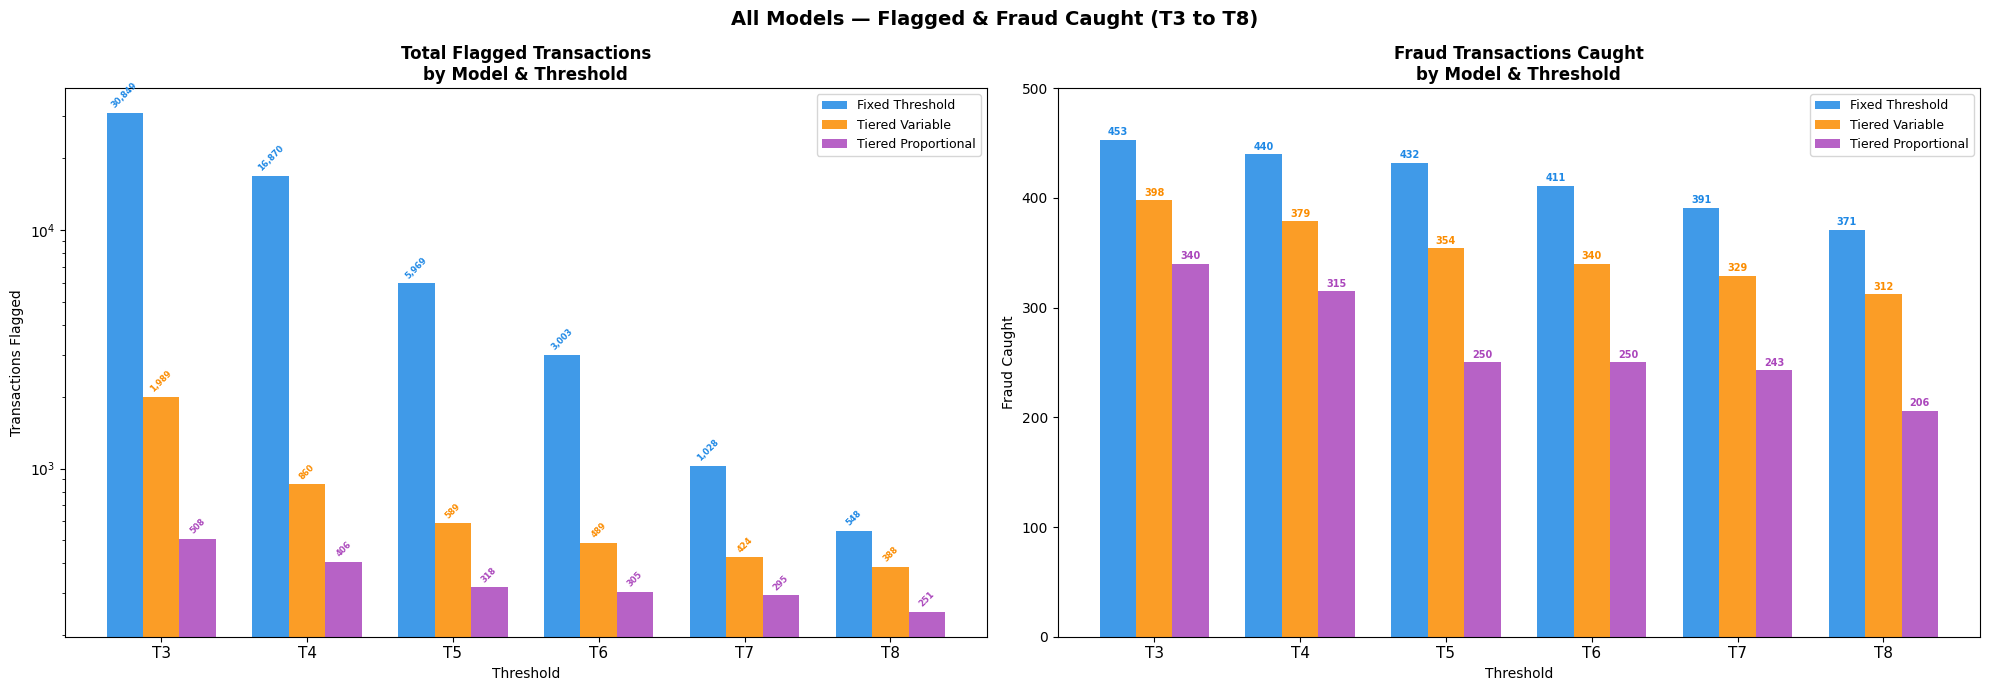

Chart saved as all_models_t3_t8.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

thresholds_labels = ['T3', 'T4', 'T5', 'T6', 'T7', 'T8']
x = range(6)
width = 0.25

# Flagged data
fixed_flagged =  [30849, 16870, 5969, 3003, 1028, 548]
tiered_flagged = [1989,  860,   589,  489,  424,  388]
prop_flagged =   [508,   406,   318,  305,  295,  251]

# Fraud caught data
fixed_caught =  [453, 440, 432, 411, 391, 371]
tiered_caught = [398, 379, 354, 340, 329, 312]
prop_caught =   [340, 315, 250, 250, 243, 206]

colors = {
    'Fixed':  '#1E88E5',
    'Tiered': '#FB8C00',
    'Prop':   '#AB47BC'
}

# --- Chart 1: Flagged ---
b1 = axes[0].bar([i - width for i in x], fixed_flagged,
                  width, label='Fixed Threshold',
                  color=colors['Fixed'], alpha=0.85)
b2 = axes[0].bar([i for i in x], tiered_flagged,
                  width, label='Tiered Variable',
                  color=colors['Tiered'], alpha=0.85)
b3 = axes[0].bar([i + width for i in x], prop_flagged,
                  width, label='Tiered Proportional',
                  color=colors['Prop'], alpha=0.85)
axes[0].set_title('Total Flagged Transactions\nby Model & Threshold',
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('Transactions Flagged')
axes[0].set_xticks(x)
axes[0].set_xticklabels(thresholds_labels, fontsize=11)
axes[0].set_xlabel('Threshold')
axes[0].legend(fontsize=9)
axes[0].set_yscale('log')
for bars, col in zip([b1, b2, b3],
                     [colors['Fixed'], colors['Tiered'],
                      colors['Prop']]):
    for bar in bars:
        val = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2,
                    val * 1.05, f'{val:,}',
                    ha='center', fontsize=6,
                    fontweight='bold', color=col, rotation=45)

# --- Chart 2: Fraud Caught ---
b4 = axes[1].bar([i - width for i in x], fixed_caught,
                  width, label='Fixed Threshold',
                  color=colors['Fixed'], alpha=0.85)
b5 = axes[1].bar([i for i in x], tiered_caught,
                  width, label='Tiered Variable',
                  color=colors['Tiered'], alpha=0.85)
b6 = axes[1].bar([i + width for i in x], prop_caught,
                  width, label='Tiered Proportional',
                  color=colors['Prop'], alpha=0.85)
axes[1].set_title('Fraud Transactions Caught\nby Model & Threshold',
                   fontweight='bold', fontsize=12)
axes[1].set_ylabel('Fraud Caught')
axes[1].set_ylim(0, 500)
axes[1].set_xticks(x)
axes[1].set_xticklabels(thresholds_labels, fontsize=11)
axes[1].set_xlabel('Threshold')
axes[1].legend(fontsize=9)
for bars, col in zip([b4, b5, b6],
                     [colors['Fixed'], colors['Tiered'],
                      colors['Prop']]):
    for bar in bars:
        val = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2,
                    val + 4, str(val),
                    ha='center', fontsize=7,
                    fontweight='bold', color=col)

plt.suptitle('All Models — Flagged & Fraud Caught (T3 to T8)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_t3_t8.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as all_models_t3_t8.png")

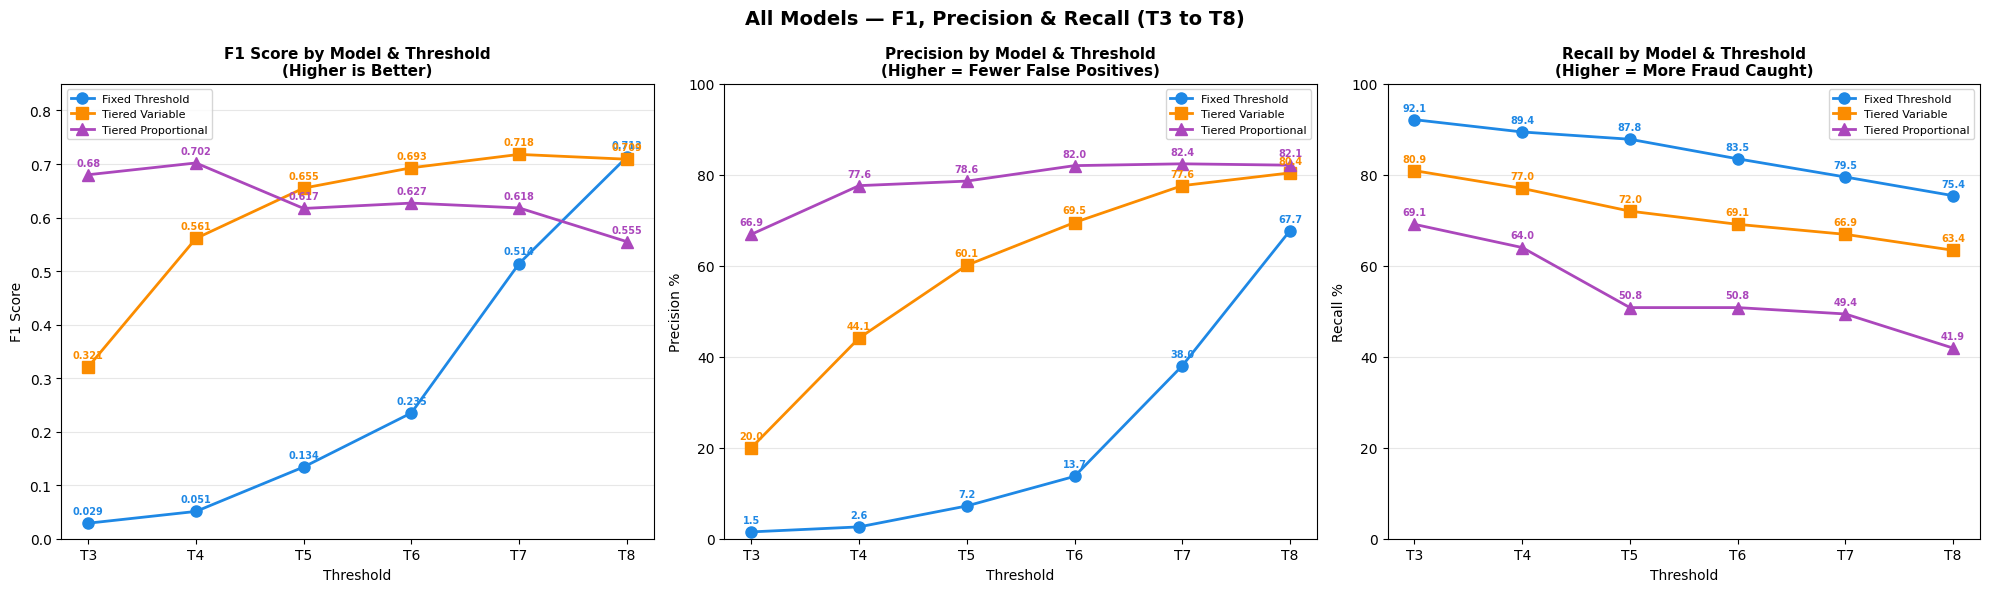

Chart saved as all_models_f1_precision_recall_t3_t8.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

thresholds_labels = ['T3', 'T4', 'T5', 'T6', 'T7', 'T8']
x = range(6)

colors = {
    'Fixed':  '#1E88E5',
    'Tiered': '#FB8C00',
    'Prop':   '#AB47BC'
}

markers = {
    'Fixed':  'o',
    'Tiered': 's',
    'Prop':   '^'
}

# F1 scores
fixed_f1 =  [0.029, 0.051, 0.134, 0.235, 0.514, 0.713]
tiered_f1 = [0.321, 0.561, 0.655, 0.693, 0.718, 0.709]
prop_f1 =   [0.680, 0.702, 0.617, 0.627, 0.618, 0.555]

# Precision
fixed_prec =  [1.5,  2.6,  7.2,  13.7, 38.0, 67.7]
tiered_prec = [20.0, 44.1, 60.1, 69.5, 77.6, 80.4]
prop_prec =   [66.9, 77.6, 78.6, 82.0, 82.4, 82.1]

# Recall
fixed_rec =  [92.1, 89.4, 87.8, 83.5, 79.5, 75.4]
tiered_rec = [80.9, 77.0, 72.0, 69.1, 66.9, 63.4]
prop_rec =   [69.1, 64.0, 50.8, 50.8, 49.4, 41.9]

def plot_line(ax, fixed, tiered, prop, title, ylabel, ylim):
    ax.plot(thresholds_labels, fixed,
            color=colors['Fixed'], linewidth=2,
            marker=markers['Fixed'], markersize=8,
            label='Fixed Threshold')
    ax.plot(thresholds_labels, tiered,
            color=colors['Tiered'], linewidth=2,
            marker=markers['Tiered'], markersize=8,
            label='Tiered Variable')
    ax.plot(thresholds_labels, prop,
            color=colors['Prop'], linewidth=2,
            marker=markers['Prop'], markersize=8,
            label='Tiered Proportional')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, ylim)
    ax.set_xlabel('Threshold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for data, col in zip([fixed, tiered, prop],
                         [colors['Fixed'], colors['Tiered'],
                          colors['Prop']]):
        for i, val in enumerate(data):
            ax.text(i, val + ylim*0.02, str(val),
                   ha='center', fontsize=7,
                   fontweight='bold', color=col)

plot_line(axes[0], fixed_f1, tiered_f1, prop_f1,
          'F1 Score by Model & Threshold\n(Higher is Better)',
          'F1 Score', 0.85)

plot_line(axes[1], fixed_prec, tiered_prec, prop_prec,
          'Precision by Model & Threshold\n(Higher = Fewer False Positives)',
          'Precision %', 100)

plot_line(axes[2], fixed_rec, tiered_rec, prop_rec,
          'Recall by Model & Threshold\n(Higher = More Fraud Caught)',
          'Recall %', 100)

plt.suptitle('All Models — F1, Precision & Recall (T3 to T8)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_f1_precision_recall_t3_t8.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as all_models_f1_precision_recall_t3_t8.png")

In [ ]:
# WHY: A clean summary table comparing the best threshold
# from each model gives stakeholders an instant clear view
# of how the three models compare at their optimal settings.

import pandas as pd

summary = pd.DataFrame({
    'Model': [
        'Fixed Threshold',
        'Tiered Variable',
        'Tiered Proportional'
    ],
    'Best Threshold': ['T8', 'T7', 'T4'],
    'Fraud Caught': [371, 329, 315],
    'Total Flagged': [548, 424, 406],
    'Recall %': [75.4, 66.9, 64.0],
    'Precision %': [67.7, 77.6, 77.6],
    'F1 Score': [0.713, 0.718, 0.702]
})

print("=" * 75)
print("BEST MODEL COMPARISON — VERIFIED RESULTS")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)
print(f"\nDataset fraud rate:          0.17%")
print(f"UK Finance benchmark recall: 67.0%")
print(f"All three models beat UK Finance benchmark: ✅")
print(f"\nWinner by F1 Score:     Tiered Variable T7  (0.718)")
print(f"Winner by Recall:       Fixed Threshold T8  (75.4%)")
print(f"Winner by Precision:    Tiered Variable T7  (77.6%)")
print(f"Winner by Least Flagged: Tiered Proportional T4 (406)")

BEST MODEL COMPARISON — VERIFIED RESULTS
              Model Best Threshold  Fraud Caught  Total Flagged  Recall %  Precision %  F1 Score
    Fixed Threshold             T8           371            548      75.4         67.7     0.713
    Tiered Variable             T7           329            424      66.9         77.6     0.718
Tiered Proportional             T4           315            406      64.0         77.6     0.702

Dataset fraud rate:          0.17%
UK Finance benchmark recall: 67.0%
All three models beat UK Finance benchmark: ✅

Winner by F1 Score:     Tiered Variable T7  (0.718)
Winner by Recall:       Fixed Threshold T8  (75.4%)
Winner by Precision:    Tiered Variable T7  (77.6%)
Winner by Least Flagged: Tiered Proportional T4 (406)


All variables rebuilt successfully


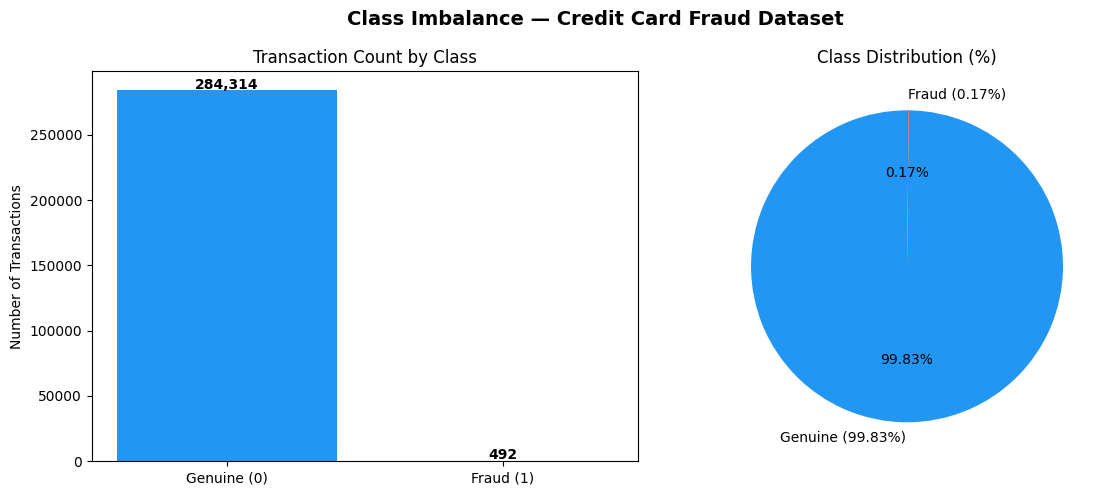

Chart 1 saved


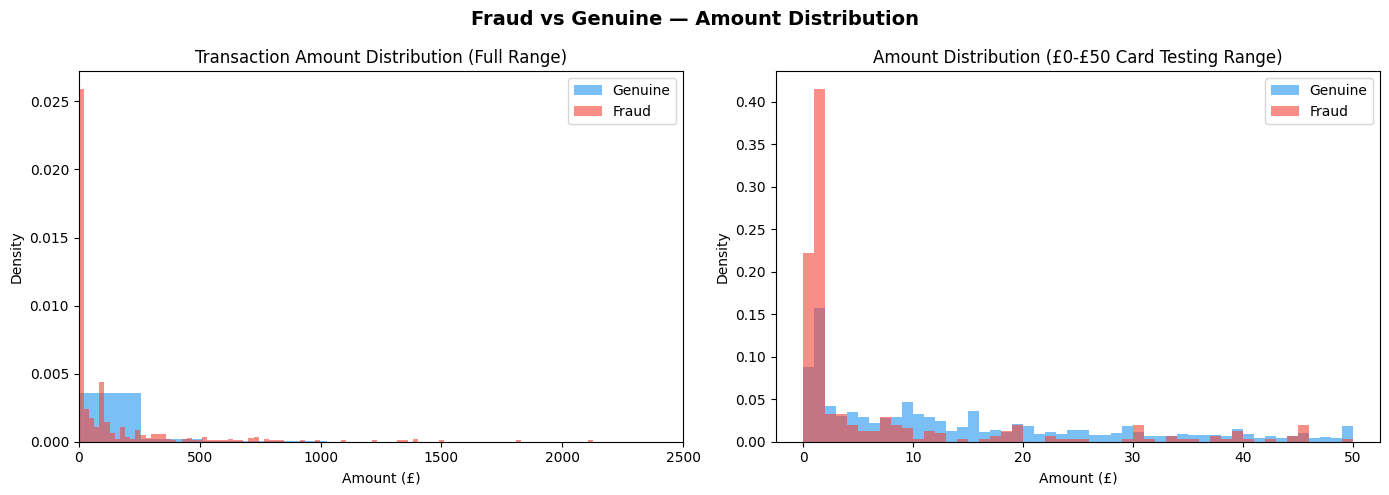

Chart 2 saved


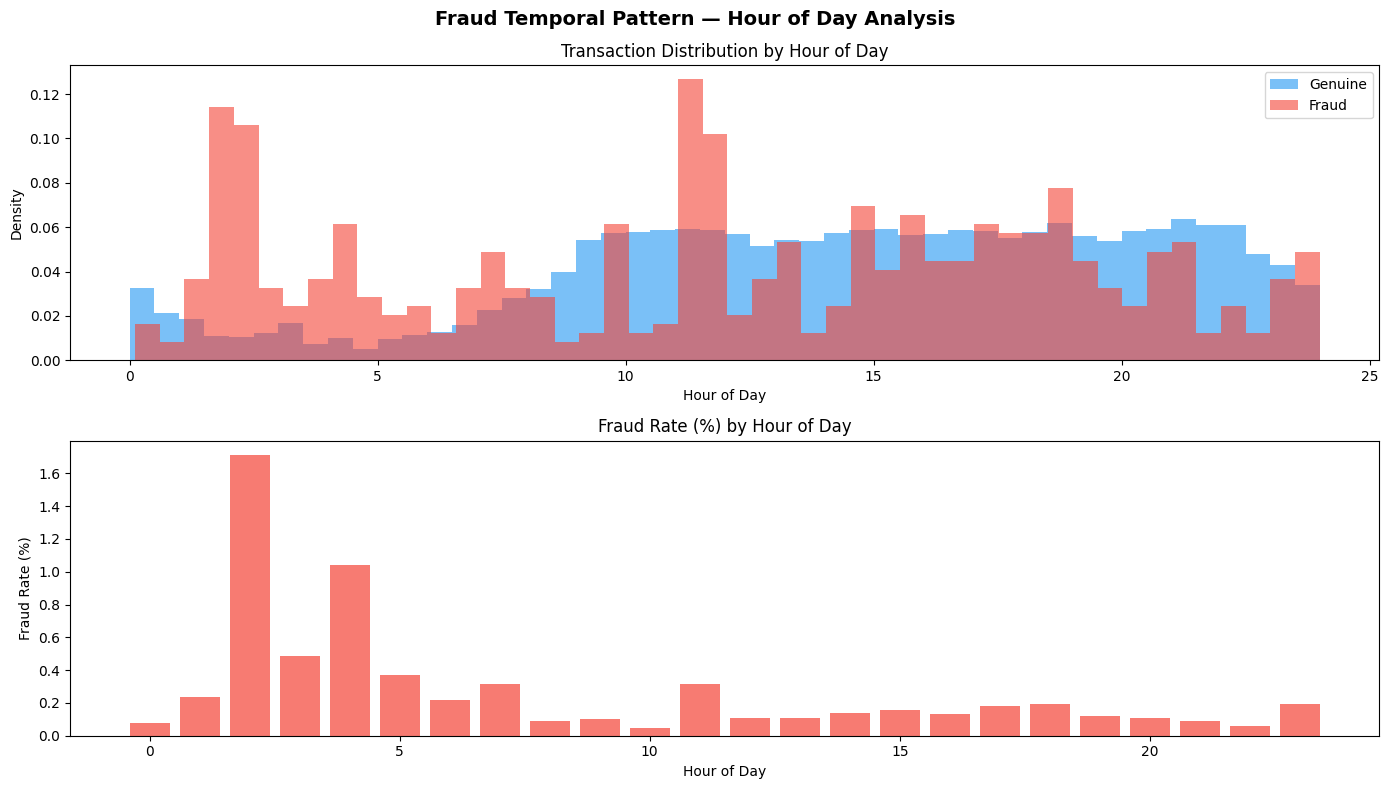

Chart 3 saved


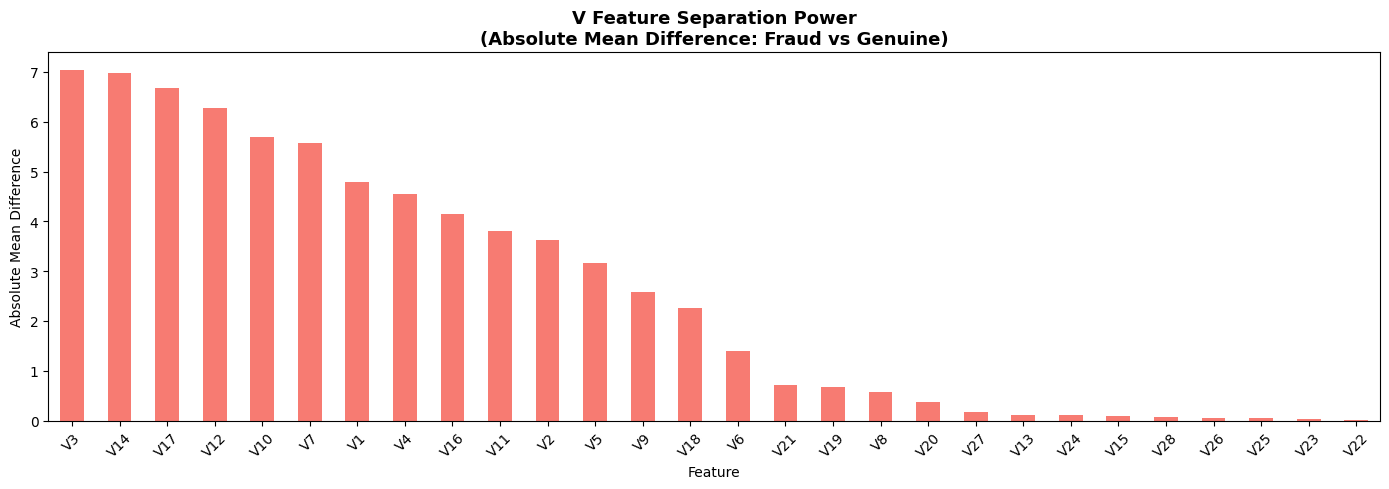

Chart 4 saved


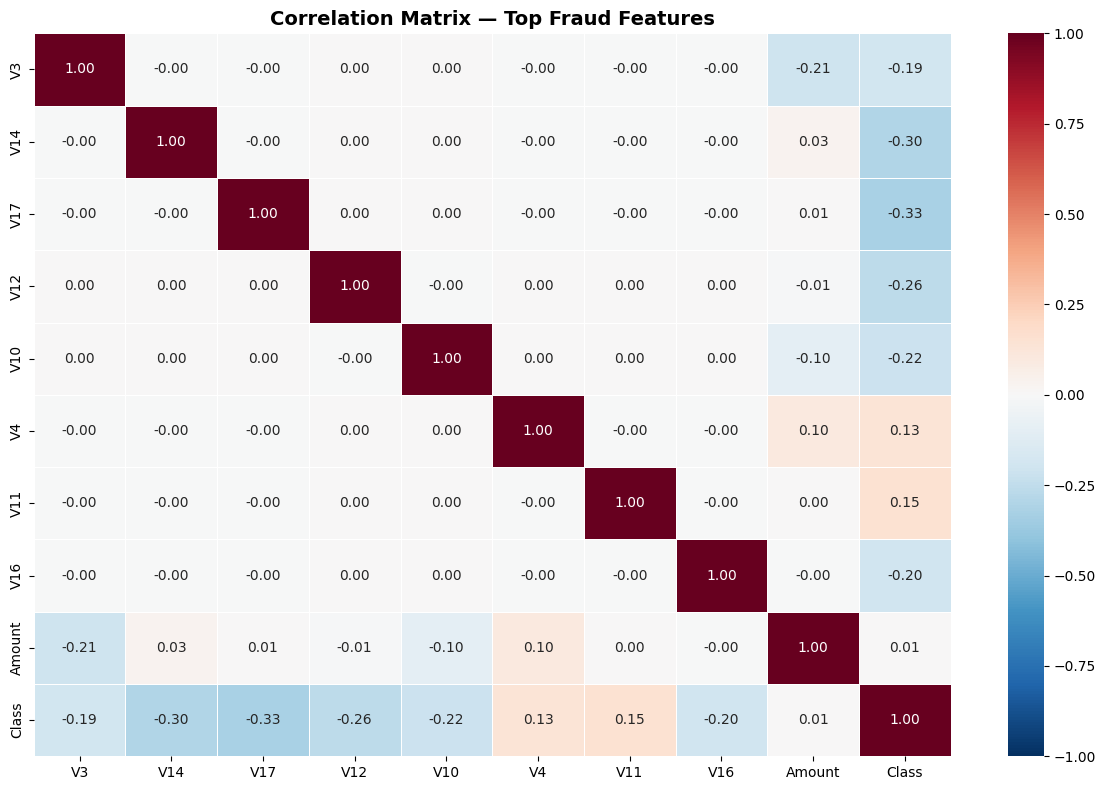

Chart 5 saved


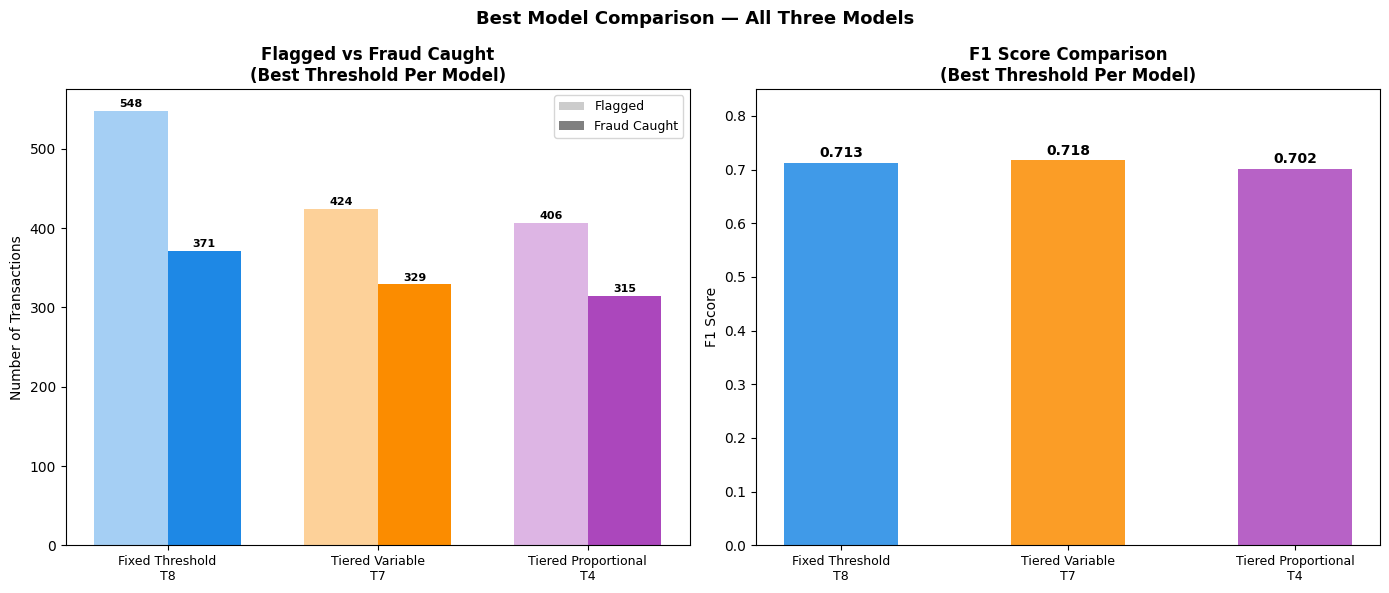

Chart 6 saved


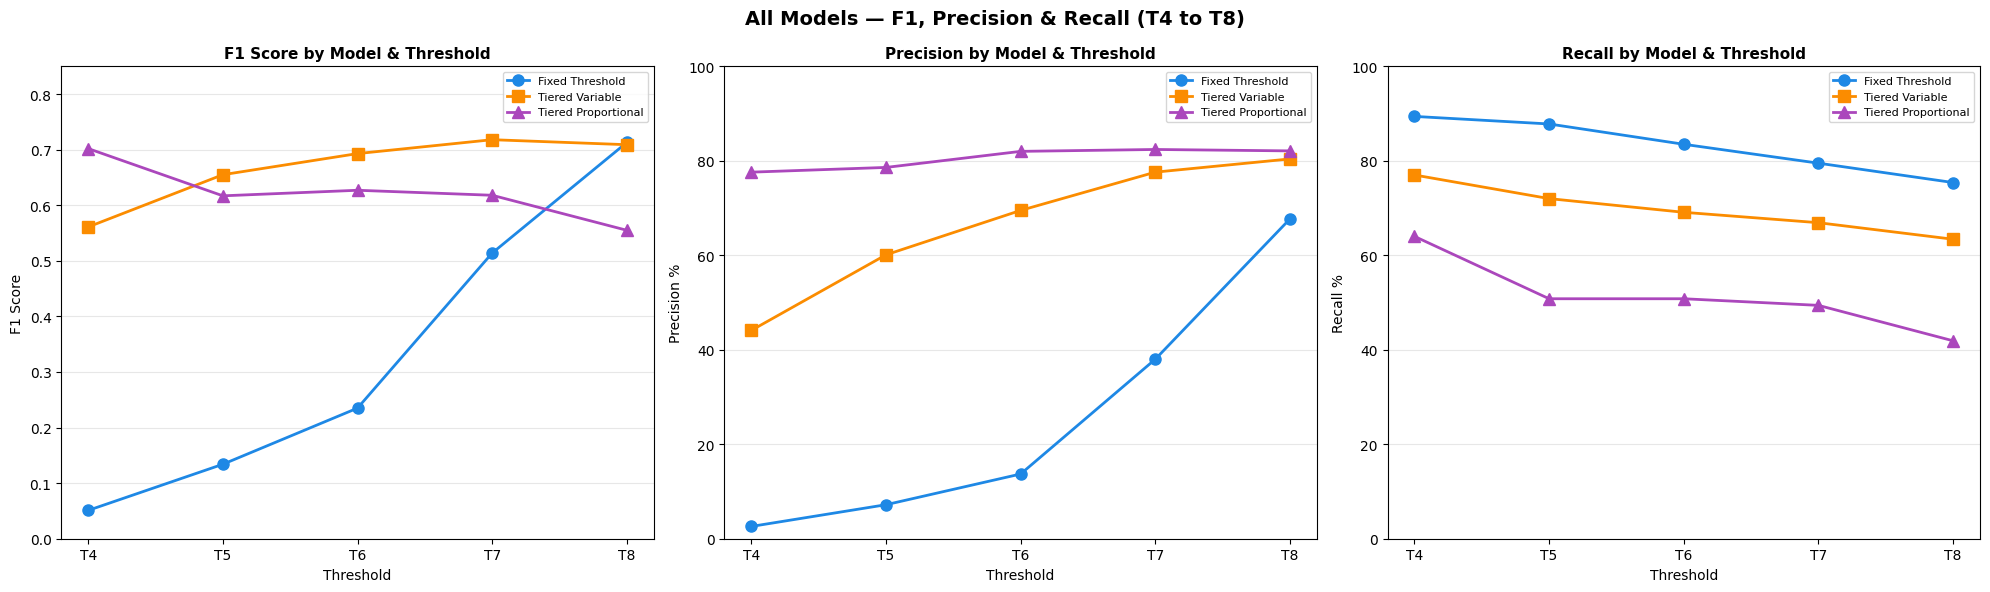

Chart 7 saved

✅ ALL CHARTS SAVED SUCCESSFULLY


In [4]:
# MASTER CHART REGENERATION CELL
# Rebuilds all key charts needed for GitHub upload

# ============================================
# SETUP — Rebuild all variables
# ============================================
df['Hour'] = (df['Time'] / 3600) % 24
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# Rebuild grad_score
all_features = [f'V{i}' for i in range(1, 29)]
band_results = []
for feature in all_features:
    feat_min = df[feature].min()
    feat_max = df[feature].max()
    band_size = (feat_max - feat_min) / 5
    for i in range(5):
        band_low = feat_min + (i * band_size)
        band_high = feat_min + ((i + 1) * band_size)
        band_data = df[(df[feature] >= band_low) & (df[feature] < band_high)]
        total = len(band_data)
        fraud_count = int(band_data['Class'].sum())
        fraud_rate = (fraud_count / total * 100) if total > 0 else 0
        band_results.append({
            'Feature': feature, 'Band': f'{i+1}/5',
            'Low': round(band_low, 2), 'High': round(band_high, 2),
            'Total': total, 'Fraud': fraud_count,
            'Legit': total - fraud_count,
            'Fraud Rate%': round(fraud_rate, 4)
        })
band_df = pd.DataFrame(band_results)

tier_max = {
    'V9': 5, 'V12': 5, 'V17': 5, 'V16': 5, 'V10': 5,
    'V11': 4, 'V14': 4, 'V3': 4, 'V7': 4, 'V18': 4,
    'V4': 3, 'V8': 3, 'V2': 3, 'V1': 3, 'V22': 3,
    'V27': 2, 'V21': 2, 'V23': 2, 'V25': 2, 'V19': 2,
    'V5': 1, 'V13': 1, 'V15': 1, 'V26': 1,
    'V24': 1, 'V6': 1, 'V20': 1, 'V28': 1
}

def fraud_rate_to_points(fraud_rate_pct, max_points):
    if fraud_rate_pct >= 75: return max_points
    elif fraud_rate_pct >= 50: return round(max_points * 0.6, 1)
    elif fraud_rate_pct >= 25: return round(max_points * 0.4, 1)
    elif fraud_rate_pct >= 1: return round(max_points * 0.2, 1)
    else: return 0

scoring_rules = []
for feature in all_features:
    max_pts = tier_max[feature]
    feat_data = band_df[band_df['Feature'] == feature].copy()
    for _, row in feat_data.iterrows():
        points = fraud_rate_to_points(row['Fraud Rate%'], max_pts)
        if points > 0:
            scoring_rules.append({
                'Feature': feature, 'Low': row['Low'],
                'High': row['High'], 'Fraud Rate%': row['Fraud Rate%'],
                'Points': points, 'Max Points': max_pts
            })
rules_df = pd.DataFrame(scoring_rules)

df['grad_score'] = 0.0
for _, rule in rules_df.iterrows():
    mask = ((df[rule['Feature']] >= rule['Low']) &
            (df[rule['Feature']] < rule['High']))
    df.loc[mask, 'grad_score'] += rule['Points']

print("All variables rebuilt successfully")

# ============================================
# CHART 1 — Class Distribution
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_counts = df['Class'].value_counts()
axes[0].bar(['Genuine (0)', 'Fraud (1)'], class_counts.values,
            color=['#2196F3', '#F44336'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
class_pct = df['Class'].value_counts(normalize=True) * 100
axes[1].pie(class_pct.values,
            labels=['Genuine (99.83%)', 'Fraud (0.17%)'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.2f%%', startangle=90)
axes[1].set_title('Class Distribution (%)')
plt.suptitle('Class Imbalance — Credit Card Fraud Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

# ============================================
# CHART 2 — Amount Distribution
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(legit['Amount'], bins=100, alpha=0.6,
             color='#2196F3', label='Genuine', density=True)
axes[0].hist(fraud['Amount'], bins=100, alpha=0.6,
             color='#F44336', label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution (Full Range)')
axes[0].set_xlabel('Amount (£)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 2500)
axes[1].hist(legit[legit['Amount'] <= 50]['Amount'], bins=50,
             alpha=0.6, color='#2196F3', label='Genuine', density=True)
axes[1].hist(fraud[fraud['Amount'] <= 50]['Amount'], bins=50,
             alpha=0.6, color='#F44336', label='Fraud', density=True)
axes[1].set_title('Amount Distribution (£0-£50 Card Testing Range)')
axes[1].set_xlabel('Amount (£)')
axes[1].set_ylabel('Density')
axes[1].legend()
plt.suptitle('Fraud vs Genuine — Amount Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

# ============================================
# CHART 3 — Fraud by Hour
# ============================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].hist(legit['Hour'], bins=48, alpha=0.6,
             color='#2196F3', label='Genuine', density=True)
axes[0].hist(fraud['Hour'], bins=48, alpha=0.6,
             color='#F44336', label='Fraud', density=True)
axes[0].set_title('Transaction Distribution by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Density')
axes[0].legend()
hourly = df.groupby(df['Hour'].astype(int))['Class'].agg(['sum','count'])
hourly['fraud_rate'] = hourly['sum'] / hourly['count'] * 100
axes[1].bar(hourly.index, hourly['fraud_rate'], color='#F44336', alpha=0.7)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
plt.suptitle('Fraud Temporal Pattern — Hour of Day Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

# ============================================
# CHART 4 — V Feature Separation
# ============================================
v_features = [f'V{i}' for i in range(1, 29)]
means_fraud = fraud[v_features].mean()
means_legit = legit[v_features].mean()
diff = (means_fraud - means_legit).abs().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
diff.plot(kind='bar', color='#F44336', alpha=0.7)
plt.title('V Feature Separation Power\n(Absolute Mean Difference: Fraud vs Genuine)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Absolute Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('v_feature_separation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

# ============================================
# CHART 5 — Correlation Matrix
# ============================================
cols = ['V3','V14','V17','V12','V10','V4','V11','V16','Amount','Class']
corr_matrix = df[cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — Top Fraud Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

# ============================================
# CHART 6 — Best Model Comparison
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = ['Fixed Threshold\nT8', 'Tiered Variable\nT7', 'Tiered Proportional\nT4']
flagged = [548, 424, 406]
caught = [371, 329, 315]
f1 = [0.713, 0.718, 0.702]
colors = ['#1E88E5', '#FB8C00', '#AB47BC']
width = 0.35
x = range(3)
for i, (f_val, c_val, col) in enumerate(zip(flagged, caught, colors)):
    axes[0].bar(i - width/2, f_val, width, color=col, alpha=0.4)
    axes[0].bar(i + width/2, c_val, width, color=col, alpha=1.0)
    axes[0].text(i - width/2, f_val + 5, f'{f_val:,}',
                ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i + width/2, c_val + 5, str(c_val),
                ha='center', fontsize=8, fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='grey', alpha=0.4, label='Flagged'),
    Patch(facecolor='grey', alpha=1.0, label='Fraud Caught')
]
axes[0].legend(handles=legend_elements, fontsize=9)
axes[0].set_title('Flagged vs Fraud Caught\n(Best Threshold Per Model)',
                   fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
bars = axes[1].bar(x, f1, color=colors, alpha=0.85, width=0.5)
axes[1].set_title('F1 Score Comparison\n(Best Threshold Per Model)',
                   fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
for bar, score in zip(bars, f1):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                score + 0.01, str(score),
                ha='center', fontweight='bold', fontsize=10)
plt.suptitle('Best Model Comparison — All Three Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('best_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved")

# ============================================
# CHART 7 — F1 Precision Recall All Models
# ============================================
thresholds_labels = ['T4', 'T5', 'T6', 'T7', 'T8']
x = range(5)
fixed_f1 =  [0.051, 0.134, 0.235, 0.514, 0.713]
tiered_f1 = [0.561, 0.655, 0.693, 0.718, 0.709]
prop_f1 =   [0.702, 0.617, 0.627, 0.618, 0.555]
fixed_prec =  [2.6,  7.2,  13.7, 38.0, 67.7]
tiered_prec = [44.1, 60.1, 69.5, 77.6, 80.4]
prop_prec =   [77.6, 78.6, 82.0, 82.4, 82.1]
fixed_rec =  [89.4, 87.8, 83.5, 79.5, 75.4]
tiered_rec = [77.0, 72.0, 69.1, 66.9, 63.4]
prop_rec =   [64.0, 50.8, 50.8, 49.4, 41.9]
colors_m = {'Fixed': '#1E88E5', 'Tiered': '#FB8C00', 'Prop': '#AB47BC'}
markers_m = {'Fixed': 'o', 'Tiered': 's', 'Prop': '^'}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
def plot_line(ax, fixed, tiered, prop, title, ylabel, ylim):
    ax.plot(thresholds_labels, fixed, color=colors_m['Fixed'],
            linewidth=2, marker=markers_m['Fixed'], markersize=8,
            label='Fixed Threshold')
    ax.plot(thresholds_labels, tiered, color=colors_m['Tiered'],
            linewidth=2, marker=markers_m['Tiered'], markersize=8,
            label='Tiered Variable')
    ax.plot(thresholds_labels, prop, color=colors_m['Prop'],
            linewidth=2, marker=markers_m['Prop'], markersize=8,
            label='Tiered Proportional')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, ylim)
    ax.set_xlabel('Threshold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
plot_line(axes[0], fixed_f1, tiered_f1, prop_f1,
          'F1 Score by Model & Threshold', 'F1 Score', 0.85)
plot_line(axes[1], fixed_prec, tiered_prec, prop_prec,
          'Precision by Model & Threshold', 'Precision %', 100)
plot_line(axes[2], fixed_rec, tiered_rec, prop_rec,
          'Recall by Model & Threshold', 'Recall %', 100)
plt.suptitle('All Models — F1, Precision & Recall (T4 to T8)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_f1_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved")
print("\n✅ ALL CHARTS SAVED SUCCESSFULLY")